# Precision at fixed candidate budgets, ranked by chromatin density -- bbox tightening on the hematoxylin_od channel

**Question.** Does moving the Otsu bbox-tightening step (seed refinement) from `gray_inverted`
onto the same `hematoxylin_od` channel the search already uses change precision@K (K = 10, 20,
30, 50), at the actual production configuration -- `MAX_PEAKS = 100` (`DECISIONS.md` D9) -- for
the three candidate-ranking axes D5 puts on the same footing: `tm_score` (D5's production
ranker), `chromatin_od` (`od51`), and `od_contrast` (`od51 - od_ctx`, D5's 2026-09-08 amendment)?

**Rebuilt to two independent audits' own correction spec**
(`Research Logs/2026-09-16-hembbox-precision-at-k-audit.md` and its round-2 follow-up), which
found that an earlier version of this notebook's "correction pass" described four required
changes but applied none of them (round-2 Finding V1), and that one of the four, as originally
specified, would have crashed the notebook outright (Finding V2). This version applies all four
together, in one rerun:

1. **Both conditions now score the same click, by construction.** The seed draw's accept/reject
   gate (the notebook-local `_check` below, not `seed_selection.build_seed` -- this is specific
   to comparing two tightening channels, not a change to production code) requires
   `tightened_template_box` **and** a readable search patch to succeed under **both**
   `hematoxylin_od` and `gray_inverted` before a candidate is accepted. Whichever annotation the
   RNG stream lands on is then tightened separately by each channel -- so `seed_ann_id` (the
   click) is identical between the two conditions on all 14 ROIs, and only the tightened box
   (size, centre) differs. Verified below (Gate 1), not assumed.
2. **`MAX_PEAKS = 100`**, the value `DECISIONS.md` D9 (2026-09-12) sets for production, not the
   `2_000_000` (effectively uncapped) this notebook ran at before. This is not a drop-in constant
   change: cell 5's own peak-count check is inverted along with it (item 3), and `MAX_PEAKS` is
   no longer passed into any `compare.Arm`'s `caps=` (item 4).
3. **The peak-count check is inverted, not just relaxed.** At the old, effectively-infinite
   `MAX_PEAKS`, `assert n_peaks < MAX_PEAKS` verified the cap wasn't limiting anything. At the
   real production value the cap is *supposed* to bind -- pre-floor peak counts run in the tens
   of thousands, `MAX_PEAKS = 100` truncates every one of them -- so the old assert would fail on
   14/14 ROIs, not because anything is wrong, but because it checks for the wrong event. It is
   replaced with `assert n_peaks == MAX_PEAKS`, which verifies the cap does what D9 says it
   should, and can still fail informatively if some ROI's response map ever has fewer than 100
   qualifying peaks.
4. **`MAX_PEAKS` is dropped from `compare.Arm(caps=...)`.** `caps` is scoped to truncation limits
   that could bind on the *returned candidate frame* an arm ranks -- the post-NMS `pool` -- not
   on `extract_peaks`'s pre-NMS `n_peaks`, a different population entirely. This was already an
   imprecise reuse when it silently never fired (`MAX_PEAKS = 2_000_000`); at `MAX_PEAKS = 100` a
   post-NMS pool landing exactly on 100 would raise `invariants.check_no_cap` and crash a correct
   run for no real reason (see this repo's `max-peaks-not-in-arm-caps` incident, same bug).
5. **`od_contrast` (`od51 - od_ctx`) is added as a third scored arm**, on the same terms as
   `chromatin_od` under D5's 2026-09-08 amendment -- it led the six-arm baseline at 2 of 4
   budgets in the notebook that shortlisted these axes, and was dropped from this comparison's
   two-arm framing without being tested under the channel change.

**What this replaces.** Earlier versions of this notebook measured the `hematoxylin_od` condition
alone and compared it against `production_seed_precision_at_k_chromatin_half_pix_fix.ipynb`'s
already-committed output as the `gray_inverted` baseline. That comparison is retired here, not
reused: that committed baseline was drawn without the joint-validity gate (item 1) and at the
old, uncapped `MAX_PEAKS` (item 2) -- differing from a corrected run on two axes at once, not
one -- so it is no longer a valid comparison partner. This notebook instead computes **both**
tightening conditions itself, from the identical click, in the same run, and compares them
directly. Its own deltas are therefore not comparable to any previously-reported number from this
notebook family.

**Scope, fixed for this run:**
- 14 ROIs, `images/extra_valid` (2 per tumour domain x 7 domains).
- 1 seed per ROI, `seed_index = 0` -- same RNG stream as every notebook in this family, walked
  under the joint-validity gate described above.
- D1/D2/D7 per `DECISIONS.md`: `TM_CCOEFF`, no `tissue_mask`, NMS radius = match radius = 7.5 um.
  D3 (`hematoxylin_od` unclipped) is the search channel for **both** conditions -- only the
  channel feeding the Otsu bbox-tightening gate changes between them.
- D9: `MAX_PEAKS = 100` before NMS, in the actual production call, not `FSConfig.max_peaks`.
- Three arms: `tm_score`, `chromatin_od` (`od51`), `od_contrast` (`od51 - od_ctx`). `od31`,
  `od_falloff` and `mask_od_mean` -- three of the six axes the original six-arm notebook
  carried -- stay out of scope; D5 puts `od_contrast` on the same footing as `chromatin_od`, the
  other two are not.
- No z-threshold sweep, no seed sweep -- single deep-floor extraction (`z = -1.5`), single NMS,
  per condition.
- **Still not template-matched.** Fixing the click removes the click/ground-truth confound; it
  does not make this an all-else-equal ranking comparison. `base_size` differs between the two
  conditions on essentially every ROI by construction -- that difference is the thing this
  notebook measures, not a nuisance to control away.

In [1]:
import gc
import time
import sys

import cv2
import numpy as np
import pandas as pd

sys.path.insert(0, '..')
from midog_utils import channels as ch
from midog_utils import chromatin as cm
from midog_utils import dataset as ds
from midog_utils import evaluate as ev
from midog_utils import find_and_suppress as fs
from midog_utils import seed_selection as ss
from midog_utils import template_match as tm
from midog_utils import compare as cp
from midog_utils.nms import nms_by_distance

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_rows', 220)

NB_T0 = time.time()

# ---------------------------------------------------------------------------------------
# Configuration. Both tightening conditions are computed in this one run, from one shared,
# jointly-valid click per ROI (see the joint-validity `_check` in `run_roi` below) -- see the
# intro markdown above for why this replaces comparing against an externally-committed baseline.
# D9: MAX_PEAKS = 100. Arms: tm_score, chromatin_od, od_contrast.
# ---------------------------------------------------------------------------------------
IMAGES_DIR = '../images/extra_valid'
SEED_INDEX = 0                       # one seed per ROI

SEARCH_CHANNEL = 'hematoxylin_od'    # D3 -- unclipped OD; the search channel for BOTH conditions
CONDITIONS = {'hem_bbox': 'hematoxylin_od', 'gray_bbox': 'gray_inverted'}  # tightening-gate channel
METHOD = cv2.TM_CCOEFF               # D1 -- unnormalized, contrast-sensitive
PEAK_MIN_DISTANCE = 7
SELF_HIT_RADIUS = 5.0
DEEP_FLOOR_Z = -1.5                  # near-unfiltered extraction floor (repo convention)
MAX_PEAKS = 100                      # D9 (2026-09-12) -- the production cap, not 2_000_000

NMS_RADIUS_UM = ev.MIDOG_RADIUS_UM   # 7.5 um -- D7: NMS radius == match radius
MATCH_RADIUS_UM = ev.MIDOG_RADIUS_UM

CFG = fs.FSConfig(channel=SEARCH_CHANNEL, base_size=tm.BASE_SIZE, scales=(1.0,), n_angles=1, flips=(False,), peak_min_distance=PEAK_MIN_DISTANCE, self_hit_radius=SELF_HIT_RADIUS)
BORDER = CFG.patch_size // 2         # 36
OTSU_WINDOW = tm.BASE_SIZE           # 51

OD_WINDOW = tm.BASE_SIZE                 # 51 -- chromatin_od / od_contrast's near window
OD_CTX_WINDOW, OD_CTX_FRAC = 121, 0.50   # od_contrast's wide-context window (D5's 2026-09-08 amendment)
OD_PAD = OD_CTX_WINDOW // 2 + 1          # 61 -- one px of margin over the 121px window's exact requirement

# rank_key -> the pool column each arm sorts on, descending, NaN last (compare._rank).
AXES = {
    'tm_score':     'score',
    'chromatin_od': 'od51',
    'od_contrast':  'od_contrast',
}

BUDGETS = (10, 20, 30, 50)           # the fixed candidate-list lengths under test

OUT_PER_ROI = '../results/precision_at_k_14roi_prodseed_chromatin_hembbox_per_roi.csv'
OUT_BY_DOMAIN = '../results/precision_at_k_14roi_prodseed_chromatin_hembbox_by_domain.csv'
OUT_RAW = '../results/precision_at_k_14roi_prodseed_chromatin_hembbox_raw.csv'
OUT_VERIF = '../results/precision_at_k_14roi_prodseed_chromatin_hembbox_verification.csv'
OUT_DELTA_PER_ROI = '../results/precision_at_k_14roi_prodseed_chromatin_hembbox_delta_per_roi.csv'
OUT_DELTA_BY_DOMAIN = '../results/precision_at_k_14roi_prodseed_chromatin_hembbox_delta_by_domain.csv'
OUT_STAT_CONTEXT = '../results/precision_at_k_14roi_prodseed_chromatin_hembbox_stat_context.csv'

print(f'budgets {BUDGETS} x 14 ROIs x 1 joint click x {len(CONDITIONS)} conditions x {len(AXES)} arms')
print(f'conditions: {CONDITIONS}')
print(f'arms: {list(AXES)}')
print(f'MAX_PEAKS = {MAX_PEAKS} (D9); NMS radius = match radius = {NMS_RADIUS_UM} um (D7)')

budgets (10, 20, 30, 50) x 14 ROIs x 1 joint click x 2 conditions x 3 arms
conditions: {'hem_bbox': 'hematoxylin_od', 'gray_bbox': 'gray_inverted'}
arms: ['tm_score', 'chromatin_od', 'od_contrast']
MAX_PEAKS = 100 (D9); NMS radius = match radius = 7.5 um (D7)


## The pipeline

Both tightening conditions -- `hem_bbox` (`hematoxylin_od` gates the Otsu tightening step) and
`gray_bbox` (`gray_inverted` gates it) -- are computed for every ROI, in this one run, from a
single shared click. `seed_selection.tightened_template_box` -- D8's seed sizing/centring
constructor -- is called once per condition, on the same accepted annotation, each call fed its
own channel; everything downstream of that (search, extraction, NMS, ranking) runs once per
condition on that condition's own `(base_size, template_xy)`. The search channel itself is always
`hematoxylin_od` (D3), for both conditions -- only the channel gating the tightening step differs.

This is confirmed safe rather than assumed: `channels.py`'s module docstring guarantees every
channel is "more object -> higher value", and both `to_gray_inverted` and `to_hematoxylin_od`
satisfy it; `tighten_box_otsu`'s `method="binary"` path (the default, used here) applies
`cv2.THRESH_BINARY + cv2.THRESH_OTSU` -- never `_INV` -- so foreground is "bright" in both
channels; and it per-patch min-max normalizes to uint8 before Otsu, so the raw scale difference
(unclipped OD floats vs. 0-255 `gray_inverted`) doesn't matter, only the polarity does. No change
to any `midog_utils` file was needed or made.

The D8 containment gate (`center_tolerance=0`), the border-safety re-check at the recentred
point, self-hit removal referenced to the recentred template centre (not the click), and ground
truth staying keyed to the click are all unchanged from the notebook this is built on
(`production_seed_precision_at_k_chromatin_half_pix_fix.ipynb`) -- applied independently per
condition. Three `compare.Arm`s -- `tm_score`, `chromatin_od` (`od51`), `od_contrast`
(`od51 - od_ctx`) -- then rank each condition's own post-NMS pool.

In [2]:
# D8 (`DECISIONS.md`, 2026-09-09; corrected 2026-09-10): seed sizing AND centring come from
# `seed_selection.tightened_template_box`, called once per condition on the shared click (see
# `run_roi`'s `_check` closure below for the joint-validity gate that guarantees the click itself
# is identical between conditions). `shape_features`/`mask_od_mean` stay dropped, as in the
# notebook this copies.


def draw_seed_with_retry(pool, rng, check_fn):
    '''Draw a row via `rng.integers`; on failure drop it and redraw on the same stream.'''
    working, retries = pool.copy(), 0
    while len(working) > 0:
        idx = int(rng.integers(len(working)))
        row = working.iloc[idx]
        result = check_fn(row)
        if result is not None:
            return row, result, retries
        working = working.drop(working.index[idx])
        retries += 1
    raise ValueError('seed pool exhausted -- no candidate passed check_fn')


def suppress(centers, scores, radius, ref_xy):
    '''NMS at `radius`, then drop the template's own self-correlation. Returns (centers, scores).

    `ref_xy` is the point the template was built from -- under D8 the accepted Otsu component's
    own bbox centre, not the raw click. SELF_HIT_RADIUS is the repo default 5.0 px
    (`FSConfig.self_hit_radius`), deliberately tighter than the match radius: the minimum spacing
    between two real MIDOG++ annotations anywhere in the dataset is 26.2 px, below the ~30 px
    match radius, so a match-radius filter could delete a legitimate neighbouring detection.
    '''
    keep = nms_by_distance(centers, scores, radius)
    c, s = centers[keep], scores[keep]
    if len(c):
        ok = np.hypot(c[:, 0] - ref_xy[0], c[:, 1] - ref_xy[1]) > SELF_HIT_RADIUS
        c, s = c[ok], s[ok]
    return c, s


def roi_files(images_dir=IMAGES_DIR):
    import os
    return sorted(f for f in os.listdir(images_dir) if f.endswith('.tiff'))


print(f'{len(roi_files())} ROIs on disk in {IMAGES_DIR}/')

14 ROIs on disk in ../images/extra_valid/


## The run

Per ROI: load both channels once, draw one click under the joint-validity gate, then run each
condition's own `matchTemplate` pass (~1-2s here at `n_angles=1, scales=(1.0,)` -- one template,
no augmentation bank), one extraction at the deep floor (capped at `MAX_PEAKS = 100`, D9), one
NMS at 7.5 um. Then, on each condition's surviving pool: one border-replicate pad at 61 px, two
`chromatin_density` calls per candidate (51px darkest-10% for `od51`, 121px darkest-50% for
`od_ctx`), `od_contrast = od51 - od_ctx`. Three `compare.Arm`s then rank and re-match each
condition's own pool independently (`compare.evaluate_arms`), so precision@K for all three arms,
within one condition, comes from the *same* candidates -- differing only in sort order. The two
conditions do **not** share a candidate pool (different template -> different response surface),
only the click and ground truth that produced them.

In [3]:
def run_condition(hem, base_size, tpl_xy, mpp, gt_eval, domain, image_id, fn, condition):
    '''Search, extract, NMS and rank one tightening condition's own template on one ROI.

    hem (np.ndarray): the search channel (hematoxylin_od, D3) -- shared by both conditions.
    base_size (int): this condition's tightened template side length.
    tpl_xy (tuple[float, float]): this condition's template centre, full-image coordinates.
    mpp (float): this ROI's microns-per-pixel.
    gt_eval (pd.DataFrame): ground truth with the click's own annotation already removed.
    domain, image_id, fn: this ROI's metadata, carried into the output context.
    condition (str): 'hem_bbox' or 'gray_bbox' -- a key into CONDITIONS and this run's output.

    Returns tuple[pd.DataFrame, pd.DataFrame, dict]: (evaluate_arms rows, check records, meta).
    '''
    t0 = time.time()
    H, W = hem.shape[:2]
    match_radius = ev.radius_px(mpp, MATCH_RADIUS_UM)
    nms_radius = ev.radius_px(mpp, NMS_RADIUS_UM)

    patch = tm.read_padded_patch(hem, *tpl_xy, CFG.patch_size)
    templates, _ = tm.build_augmentations(patch, base_size, CFG.scales, CFG.n_angles, CFG.flips)
    PAD = max((t.shape[0] - 1) // 2 for t in templates)
    hem_p = cv2.copyMakeBorder(hem, PAD, PAD, PAD, PAD, borderType=cv2.BORDER_REPLICATE)
    fused_p, _, valid_p = tm.fused_response(hem_p, templates, CFG.scale_normalize, method=METHOD)
    fused = fused_p[PAD:PAD + H, PAD:PAD + W]
    valid = valid_p[PAD:PAD + H, PAD:PAD + W]
    assert bool(valid.all()), f'{fn}/{condition}: padding left part of the ROI unreachable (PAD={PAD})'
    del hem_p, fused_p, valid_p
    gc.collect()

    med, mad = tm.robust_stats(fused, valid)
    cut = med + DEEP_FLOOR_Z * mad
    centers, scores = tm.extract_peaks(fused, valid, PEAK_MIN_DISTANCE, cut, MAX_PEAKS)
    n_peaks = len(centers)
    # D9: MAX_PEAKS is meant to bind here, not stay clear of it -- the old `n_peaks < MAX_PEAKS`
    # verified the opposite thing, appropriate only at the old, effectively-uncapped value.
    assert n_peaks == MAX_PEAKS, f'{fn}/{condition}: MAX_PEAKS did not bind (n_peaks={n_peaks}) -- pre-floor pool is smaller than the D9 cap on this ROI'

    # self-hit diagnostics (cited in the checks section below, for the 403.tiff mechanism): is
    # the template's own centre even a raw peak that clears the MAX_PEAKS cutoff score?
    ix, iy = int(round(tpl_xy[0])), int(round(tpl_xy[1]))
    self_score = float(fused[iy, ix]) if valid[iy, ix] else float('nan')
    cutoff_score = float(scores.min()) if len(scores) else float('nan')

    c, s = suppress(centers, scores, nms_radius, tpl_xy)
    assert bool(np.all(np.diff(s) <= 0)), f'{fn}/{condition}: post-NMS pool is not score-descending'
    pool = pd.DataFrame({'cx': c[:, 0], 'cy': c[:, 1], 'score': s})

    d_seed = np.hypot(pool['cx'] - tpl_xy[0], pool['cy'] - tpl_xy[1])
    n_near_seed = int((d_seed <= match_radius).sum())

    del fused, valid, templates, patch, centers, scores, c, s
    gc.collect()

    # --- chromatin axes on the NMS survivors -- one pad covers od51 and od_ctx -----------------
    hem_pad = cv2.copyMakeBorder(hem, OD_PAD, OD_PAD, OD_PAD, OD_PAD, cv2.BORDER_REPLICATE)
    px = pool['cx'].to_numpy() + OD_PAD
    py = pool['cy'].to_numpy() + OD_PAD
    pool['od51'] = [cm.chromatin_density(hem_pad, x, y, window=OD_WINDOW) for x, y in zip(px, py)]
    pool['od_ctx'] = [cm.chromatin_density(hem_pad, x, y, window=OD_CTX_WINDOW, frac=OD_CTX_FRAC) for x, y in zip(px, py)]
    pool['od_contrast'] = pool['od51'] - pool['od_ctx']
    n_od_nan = int(pool[['od51', 'od_ctx']].isna().sum().sum())
    assert n_od_nan == 0, f'{fn}/{condition}: {n_od_nan} NaN od51/od_ctx survived the {OD_PAD}px pad'
    del hem_pad
    gc.collect()

    # --- three arms, one pool, independent rank + re-match per arm -----------------------------
    # caps=() -- not (MAX_PEAKS,): MAX_PEAKS bounds n_peaks (pre-NMS), not len(pool) (post-NMS),
    # which check_no_cap actually inspects here. See intro markdown item 4.
    arms = [cp.Arm(name, (lambda d=pool: d), rank_key=key, seeded=True, z=DEEP_FLOOR_Z, z_dependent=True, nms_radius=nms_radius, caps=(), coverage_key=f'{fn}/{condition}') for name, key in AXES.items()]
    ctx = dict(file_name=fn, tumor_type=domain, image_id=image_id, condition=condition, tighten_channel=CONDITIONS[condition], base_size=base_size, tpl_cx=tpl_xy[0], tpl_cy=tpl_xy[1], map_median=round(float(med), 5), mad_scale=round(float(mad), 5), mpp=mpp)
    checks = []
    out = cp.evaluate_arms(arms, gt_eval, match_radius, roi_shape=(H, W), mpp=mpp, budgets=BUDGETS, context=ctx, checks=checks)

    checks.append(dict(check='seed_annulus_empty', label=f'{fn}/{condition}', n_near_seed=n_near_seed, match_radius_px=round(match_radius, 3), passed=bool(n_near_seed == 0)))
    checks.append(dict(check='max_peaks_binds', label=f'{fn}/{condition}', n_peaks=n_peaks, max_peaks=MAX_PEAKS, passed=bool(n_peaks == MAX_PEAKS)))

    meta = dict(file_name=fn, condition=condition, tighten_channel=CONDITIONS[condition], base_size=base_size, tpl_cx=tpl_xy[0], tpl_cy=tpl_xy[1], mpp=mpp, n_peaks_preNMS=n_peaks, self_score=round(self_score, 3), cutoff_score=round(cutoff_score, 3), self_score_clears_cutoff=bool(self_score >= cutoff_score) if np.isfinite(self_score) else None, n_detections=len(pool), n_near_seed_annulus=n_near_seed, match_radius_px=match_radius, nms_radius_px=nms_radius, map_median=float(med), mad_scale=float(mad), t_total_s=round(time.time() - t0, 1))
    print(f"  [{fn}/{condition}] base={base_size:3d} n_detections={len(pool):4d} [{meta['t_total_s']:.1f}s]", flush=True)
    return out, pd.DataFrame(checks), meta


def run_roi(fn, image_id, domain, anns):
    '''Draw one joint-valid click for this ROI and run both tightening conditions on it.

    fn (str): the ROI's file name.
    image_id (int): this ROI's image_id, seeds the RNG stream ([SEED_INDEX, image_id]).
    domain (str): this ROI's tumour domain.
    anns (pd.DataFrame): the full annotation table.

    Returns tuple[pd.DataFrame, pd.DataFrame, list[dict], dict]: (both conditions'
    evaluate_arms rows, both conditions' check records, both conditions' meta dicts,
    this ROI's shared-click meta).
    '''
    path = f'{IMAGES_DIR}/{fn}'
    rgb = ds.load_roi(path)
    mpp = ds.roi_mpp(path)
    roi_shape = rgb.shape
    hem = ch.to_channel(rgb, CONDITIONS['hem_bbox'])
    gray_inv = ch.to_channel(rgb, CONDITIONS['gray_bbox'])
    del rgb
    gc.collect()

    # --- the click: accepted only if BOTH channels' Otsu gate (and the resulting patch's border
    # safety) succeed -- guarantees the two conditions differ only in the tightened box, never in
    # which annotation got clicked. Notebook-local: this comparison's own requirement, not a
    # change to seed_selection.build_seed (see intro markdown item 1). -----------------------------
    gt = ds.image_annotations(anns, fn)
    seed_pool, flagged = ss.agreement_pool(gt[gt['category_id'] == ds.MITOTIC])
    seed_pool = ss.border_filter(seed_pool, BORDER, roi_shape)
    rng = np.random.default_rng([SEED_INDEX, image_id])

    def _check(row):
        r_hem = ss.tightened_template_box(hem, float(row['cx']), float(row['cy']), otsu_window=OTSU_WINDOW)
        r_gray = ss.tightened_template_box(gray_inv, float(row['cx']), float(row['cy']), otsu_window=OTSU_WINDOW)
        if r_hem is None or r_gray is None:
            return None
        if tm.read_padded_patch(hem, r_hem[1], r_hem[2], CFG.patch_size) is None:
            return None
        if tm.read_padded_patch(hem, r_gray[1], r_gray[2], CFG.patch_size) is None:
            return None
        return dict(hem_bbox=r_hem, gray_bbox=r_gray)

    seed, r_by_condition, n_retries = draw_seed_with_retry(seed_pool, rng, _check)
    seed_xy = (float(seed['cx']), float(seed['cy']))  # D8 item 3: ground truth stays the click
    seed_ann_id = int(seed['ann_id'])
    gt_eval = gt[gt['ann_id'] != seed_ann_id].reset_index(drop=True)
    n_gt = int((gt_eval['category_id'] == ds.MITOTIC).sum())

    out_frames, check_frames, cond_metas = [], [], []
    for condition, r in r_by_condition.items():
        base_size, tpl_cx, tpl_cy = r
        tpl_xy = (float(tpl_cx), float(tpl_cy))
        out, checks, meta = run_condition(hem, base_size, tpl_xy, mpp, gt_eval, domain, image_id, fn, condition)
        meta['n_gt_mitotic'] = n_gt
        meta['tpl_offset_px'] = round(float(np.hypot(tpl_xy[0] - seed_xy[0], tpl_xy[1] - seed_xy[1])), 3)
        out_frames.append(out)
        check_frames.append(checks)
        cond_metas.append(meta)

    del hem, gray_inv
    gc.collect()

    roi_meta = dict(file_name=fn, tumor_type=domain, image_id=image_id, seed_ann_id=seed_ann_id, n_retries=n_retries, contested_seed_tier=bool(flagged), n_gt_mitotic=n_gt)
    return pd.concat(out_frames, ignore_index=True), pd.concat(check_frames, ignore_index=True), cond_metas, roi_meta

In [4]:
images, annotations = ds.load_annotations('../databases/MIDOG++.json')
ds.check_invariants(annotations)
meta_ix = images.set_index('file_name')[['image_id', 'tumor_type']]

files = roi_files()
missing = sorted(set(files) - set(meta_ix.index))
assert not missing, f'.tiff on disk absent from the annotation DB: {missing}'
assert len(files) == 14, f'expected 14 ROIs in {IMAGES_DIR}/, found {len(files)}'

t_run = time.time()
out_frames, check_frames, cond_meta_rows, roi_meta_rows = [], [], [], []
for fn in files:
    image_id = int(meta_ix.loc[fn, 'image_id'])
    domain = meta_ix.loc[fn, 'tumor_type']
    out, checks, cond_metas, roi_meta = run_roi(fn, image_id, domain, annotations)
    out_frames.append(out)
    check_frames.append(checks)
    cond_meta_rows.extend(cond_metas)
    roi_meta_rows.append(roi_meta)
    print(f"[{fn}] {domain:32s} seed_ann_id={roi_meta['seed_ann_id']} n_retries={roi_meta['n_retries']} n_gt={roi_meta['n_gt_mitotic']}", flush=True)
    gc.collect()

RAW = pd.concat(out_frames, ignore_index=True)
VERIF = pd.concat(check_frames, ignore_index=True)
ROI = pd.DataFrame(cond_meta_rows).set_index(['file_name', 'condition'])
ROI_CLICK = pd.DataFrame(roi_meta_rows).set_index('file_name')  # the one click shared by both conditions, per ROI

print(f'\n{len(files)} ROIs x {len(CONDITIONS)} conditions x {len(BUDGETS)} budgets x {len(AXES)} arms = {len(RAW)} rows in {time.time() - t_run:.0f}s')
ROI[['base_size', 'tpl_offset_px', 'n_gt_mitotic', 'n_detections', 'n_peaks_preNMS', 'match_radius_px', 'nms_radius_px', 'map_median', 'mad_scale', 't_total_s']].round(3)

  [013.tiff/hem_bbox] base= 39 n_detections=  98 [2.7s]


  [013.tiff/gray_bbox] base= 39 n_detections=  97 [2.4s]


[013.tiff] human breast cancer              seed_ann_id=249 n_retries=1 n_gt=17


  [094.tiff/hem_bbox] base= 23 n_detections=  98 [1.9s]


  [094.tiff/gray_bbox] base= 25 n_detections=  96 [1.9s]


...

  [548.tiff/hem_bbox] base= 27 n_detections=  98 [1.8s]


  [548.tiff/gray_bbox] base= 29 n_detections=  98 [1.8s]


[548.tiff] human melanoma                   seed_ann_id=25804 n_retries=0 n_gt=238



14 ROIs x 2 conditions x 4 budgets x 3 arms = 336 rows in 105s


base_size  tpl_offset_px  n_gt_mitotic  n_detections  n_peaks_preNMS  match_radius_px  nms_radius_px  map_median  mad_scale  t_total_s
file_name condition                                                                                                                                        
013.tiff  hem_bbox          39          1.118            17            98             100           33.139         33.139      -0.013      0.143        2.7
          gray_bbox         39          2.500            17            97             100           33.139         33.139      -0.012      0.151        2.4
094.tiff  hem_bbox          23          2.693            81            98             100           32.630         32.630      -0.002      0.038        1.9
          gray_bbox         25          2.500            81            96             100           32.630         32.630      -0.003      0.046        1.9
201.tiff  hem_bbox          29          5.000            17            97             100           30.222         30.222      -0.006      0.263        1.7
          gray_bbox         51          0.500            17            98             100           30.222         30.222      -0.028      0.612        1.9
233.tiff  hem_bbox          23          0.000            17            96             100           30.222         30.222      -0.009      0.104        1.6
          gray_bbox         25          1.414            17            97             100           30.222         30.222      -0.014      0.157        2.1
245.tiff  hem_bbox          23          5.385            89            98             100           30.222         30.222      -0.002      0.077        1.7
          gray_bbox         51          0.000            89            97             100           30.222         30.222      -0.001      0.202        2.0
246.tiff  hem_bbox          27          2.500           115            94             100           30.222         30.222      -0.002      0.110        1.7
          gray_bbox         41          8.515           115            96             100           30.222         30.222      -0.005      0.166        1.9
300.tiff  hem_bbox          25          4.123           180            99             100           29.609         29.609      -0.011      0.231        2.0
          gray_bbox         49          2.500           180            99             100           29.609         29.609      -0.086      0.505        2.0
301.tiff  hem_bbox          33          4.500           217            99             100           29.609         29.609      -0.018      0.130        1.8
          gray_bbox         41          5.500           217            98             100           29.609         29.609      -0.014      0.202        1.9
402.tiff  hem_bbox          25          2.000           104            98             100           33.139         33.139      -0.024      0.540        2.2
          gray_bbox         29          1.803           104            98             100           33.139         33.139      -0.058      0.871        2.2
403.tiff  hem_bbox          31          4.924            52            95             100           33.060         33.060      -0.002      0.284        2.2
          gray_bbox         51          2.000            52            98             100           33.060         33.060      -0.007      0.718        2.6
459.tiff  hem_bbox          31          1.000           130            99             100           30.222         30.222      -0.027      0.415        1.8
          gray_bbox         33          0.707           130            99             100           30.222         30.222      -0.045      0.531        1.7
460.tiff  hem_bbox          41          3.905            35            99             100           30.222         30.222      -0.117      0.868        1.8
          gray_bbox         47          4.472            35            99             100           30.222         30.222

## Checks before any table

Three pipeline invariants, checked per (ROI, condition): the deep-floor pool clears the largest
budget, `budget_delivered == budget` at every K, and (D9) `MAX_PEAKS` actually binds --
`n_peaks_preNMS == MAX_PEAKS` -- confirming the cap does what it is meant to at the production
value rather than sitting slack. `invariants.check_nms_radius` (D7) is already asserted per (ROI,
condition, arm) inside `evaluate_arms`, above, and is already sitting in `VERIF`; `check_no_cap`
is also called there but is vacuous here by construction (`caps=()`, see the pipeline cell's own
comment) and is not treated as evidence of anything.

The `seed_annulus_empty` check -- no surviving candidate lies within one match radius of the
removed seed -- passes cleanly here on all 28 (ROI, condition) runs. The one exception this
notebook family has ever measured (`403.tiff`, at the old uncapped `MAX_PEAKS`) does not recur at
the production cap; the code cell below re-derives why from the stored peak-extraction
diagnostics rather than asserting it.

In [5]:
assert (ROI['n_detections'] >= max(BUDGETS)).all(), 'a deep-floor pool did not clear the largest budget -- see ROI[\'n_detections\']'
assert (RAW['budget_delivered'] == RAW['budget']).all(), 'a budget row was starved -- the deep floor did not have enough survivors somewhere'
assert (ROI['n_peaks_preNMS'] == MAX_PEAKS).all(), 'MAX_PEAKS did not bind on every (ROI, condition) -- see ROI[\'n_peaks_preNMS\']'

seed_annulus_passed = bool((ROI['n_near_seed_annulus'] == 0).all())
n_annulus_violations = int((ROI['n_near_seed_annulus'] > 0).sum())
print(f"seed_annulus_empty: {'passed on all 28 (ROI, condition) runs' if seed_annulus_passed else f'violated on {n_annulus_violations}/28'}")
if not seed_annulus_passed:
    print(ROI.loc[ROI['n_near_seed_annulus'] > 0, ['n_near_seed_annulus', 'base_size']])

VERIF = pd.concat([VERIF, pd.DataFrame([
    dict(check='deep_pool_covers_max_budget', label='ALL', passed=bool((ROI['n_detections'] >= max(BUDGETS)).all())),
    dict(check='no_starvation_any_budget', label='ALL', passed=bool((RAW['budget_delivered'] == RAW['budget']).all())),
    dict(check='max_peaks_binds_all', label='ALL', passed=bool((ROI['n_peaks_preNMS'] == MAX_PEAKS).all())),
    dict(check='seed_annulus_empty', label='ALL', passed=seed_annulus_passed, note=f'{n_annulus_violations}/28 (ROI, condition) runs violated'),
])], ignore_index=True)
VERIF.to_csv(OUT_VERIF, index=False)
print(f'{len(VERIF)} verification records so far -> {OUT_VERIF} (Gate 1, below, appends more -- see its own final tally)')

_hard_checks = VERIF[VERIF['check'] != 'no_cap']
print(f"  passed so far: {int(_hard_checks['passed'].sum())} / {len(_hard_checks)}")
assert _hard_checks['passed'].all(), 'a pipeline-invariant check failed -- read the verification CSV'

seed_annulus_empty: passed on all 28 (ROI, condition) runs


228 verification records so far -> ../results/precision_at_k_14roi_prodseed_chromatin_hembbox_verification.csv (Gate 1, below, appends more -- see its own final tally)
  passed so far: 144 / 144


## The 403.tiff `seed_annulus_empty` exception -- re-derived here, not carried forward

`seed_annulus_empty` passed cleanly on all 28 (ROI, condition) runs above, at `MAX_PEAKS = 100`.
This notebook family's one prior exception was `403.tiff`, at the old effectively-uncapped
`MAX_PEAKS` -- the cell below re-derives, with one uncapped extraction per condition on `403.tiff`
alone, why that exception doesn't recur at the production cap, rather than asserting a number in a
comment.

**Correction, after an independent audit**
(`Research Logs/2026-09-16-hembbox-precision-at-k-audit-round3.md`, Findings F2/F5): an earlier
version of this cell claimed the survivor's rank was "~3282nd of ~17,600-54,000 pre-NMS
candidates" without computing either number in any cell -- both were carried forward from an
earlier notebook in this family and never re-verified against this notebook's own config. The
borrowed figure was also wrong on its own terms: 17,626 doesn't match either of *this* run's own
uncapped pool sizes (53,746 for `hem_bbox`, 34,638 for `gray_bbox`, both below). The geometry (the
0.046 px margin, the D8 half-pixel anchor) was already correct and is unaffected; only the rank
number was asserted rather than derived, and the conclusion it supports is, if anything, stronger
with the corrected number (further below 100, not less).

In [6]:
MAX_PEAKS_UNCAPPED = 10_000_000  # 403.tiff only, to find where the seed_annulus_empty survivor actually ranked


def uncapped_annulus_trace(hem, base_size, tpl_xy, mpp, condition):
    '''One uncapped matchTemplate + extraction pass on one (ROI, condition), to locate and rank
    any seed_annulus_empty survivor against the full response map -- MAX_PEAKS=100 truncates
    before NMS ever runs, so this is the only way to see where a capped-away candidate actually sat.

    hem (np.ndarray): the search channel.
    base_size (int): this condition's tightened template size.
    tpl_xy (tuple[float, float]): this condition's template centre (the D8 anchor).
    mpp (float): this ROI's microns-per-pixel.
    condition (str): 'hem_bbox' or 'gray_bbox', carried into the output rows only.

    Returns pd.DataFrame: one row per annulus survivor (empty if none), with its raw-score rank.
    '''
    H, W = hem.shape[:2]
    match_radius = ev.radius_px(mpp, MATCH_RADIUS_UM)
    nms_radius = ev.radius_px(mpp, NMS_RADIUS_UM)
    patch = tm.read_padded_patch(hem, *tpl_xy, CFG.patch_size)
    templates, _ = tm.build_augmentations(patch, base_size, CFG.scales, CFG.n_angles, CFG.flips)
    PAD = max((t.shape[0] - 1) // 2 for t in templates)
    hem_p = cv2.copyMakeBorder(hem, PAD, PAD, PAD, PAD, borderType=cv2.BORDER_REPLICATE)
    fused_p, _, valid_p = tm.fused_response(hem_p, templates, CFG.scale_normalize, method=METHOD)
    fused = fused_p[PAD:PAD + H, PAD:PAD + W]
    valid = valid_p[PAD:PAD + H, PAD:PAD + W]
    med, mad = tm.robust_stats(fused, valid)
    cut = med + DEEP_FLOOR_Z * mad
    centers, scores = tm.extract_peaks(fused, valid, PEAK_MIN_DISTANCE, cut, MAX_PEAKS_UNCAPPED)
    n_peaks = len(centers)
    keep = nms_by_distance(centers, scores, nms_radius)
    c, s = centers[keep], scores[keep]
    self_hit = np.hypot(c[:, 0] - tpl_xy[0], c[:, 1] - tpl_xy[1]) <= SELF_HIT_RADIUS
    c_kept, s_kept = c[~self_hit], s[~self_hit]
    d_kept = np.hypot(c_kept[:, 0] - tpl_xy[0], c_kept[:, 1] - tpl_xy[1])
    annulus_idx = np.where(d_kept <= match_radius)[0]
    self_peak_xy = centers[np.argmax(scores)]
    rows = []
    for i in annulus_idx:
        cxp, cyp = c_kept[i]
        rows.append(dict(condition=condition, cx=round(float(cxp), 3), cy=round(float(cyp), 3),
                         score=round(float(s_kept[i]), 3),
                         rank_1indexed=int(np.sum(scores > s_kept[i])) + 1, n_peaks_uncapped=n_peaks,
                         dist_to_anchor_px=round(float(np.hypot(cxp - tpl_xy[0], cyp - tpl_xy[1])), 3),
                         dist_to_self_peak_px=round(float(np.hypot(cxp - self_peak_xy[0], cyp - self_peak_xy[1])), 3),
                         nms_radius_px=round(nms_radius, 4)))
    return pd.DataFrame(rows)


rgb_403 = ds.load_roi(f'{IMAGES_DIR}/403.tiff')
hem_403 = ch.to_channel(rgb_403, SEARCH_CHANNEL)
mpp_403 = ds.roi_mpp(f'{IMAGES_DIR}/403.tiff')
annulus_traces = []
for condition in CONDITIONS:
    base_size = int(ROI.loc[('403.tiff', condition), 'base_size'])
    tpl_xy = (float(ROI.loc[('403.tiff', condition), 'tpl_cx']), float(ROI.loc[('403.tiff', condition), 'tpl_cy']))
    annulus_traces.append(uncapped_annulus_trace(hem_403, base_size, tpl_xy, mpp_403, condition))
del rgb_403, hem_403
gc.collect()

ANNULUS_TRACE = pd.concat(annulus_traces, ignore_index=True)
print(f'403.tiff uncapped annulus trace -- {len(ANNULUS_TRACE)} survivor(s) across both conditions:')
print(ANNULUS_TRACE.to_string(index=False) if len(ANNULUS_TRACE) else '  (none)')

# D8 half-pixel anchor: (x0+x1-1)/2 is a half-integer whenever the tightened bbox has an even
# side. Checked per condition, not pooled into one ambiguous "8/14" (audit Finding F11).
is_half = lambda v: bool(abs((float(v) * 2) % 2 - 1) < 1e-6)
half_pixel = ROI.reset_index()
half_pixel['half_pixel_anchor'] = [is_half(x) or is_half(y) for x, y in zip(half_pixel['tpl_cx'], half_pixel['tpl_cy'])]
n_half = half_pixel.groupby('condition')['half_pixel_anchor'].sum()
at_least_one = int(half_pixel.groupby('file_name')['half_pixel_anchor'].any().sum())
print(f"\nhalf-pixel D8 anchors: hem_bbox {int(n_half['hem_bbox'])}/14, gray_bbox {int(n_half['gray_bbox'])}/14, "
      f"at least one condition {at_least_one}/14")

403.tiff uncapped annulus trace -- 1 survivor(s) across both conditions:
condition     cx     cy  score  rank_1indexed  n_peaks_uncapped  dist_to_anchor_px  dist_to_self_peak_px  nms_radius_px
 hem_bbox 2255.0 2988.0  2.217           4445             53746             32.898                33.106        33.0599

half-pixel D8 anchors: hem_bbox 8/14, gray_bbox 9/14, at least one condition 12/14


## Gate 1 -- the tightened box reproduces independently, and the joint gate is checked against each channel's own solo draw

Two separate things, replacing the single `build_seed`-reproduction gate the notebook this is
built on used (that check doesn't apply here unmodified: `ss.build_seed` draws under a
single-channel gate, and this notebook's draw is deliberately stricter -- see intro item 1 -- so
a straight equality assert against it would fail by design on any ROI where the two channels'
gates disagree, not because anything is wrong).

1. **Reproduction.** `ss.tightened_template_box`, called fresh (a separately reloaded image, not
   the arrays already in memory) on each channel at the click `run_roi` already accepted, must
   return the same `(base_size, template_xy)` `run_roi` stored for that condition. This is the
   part of the original Gate 1 that is still meaningful: it does not test the channel wiring
   (both call sites are handed the same freshly-loaded channel array either way) -- it tests that
   the inline pipeline cut the template it says it did.
2. **Solo vs. joint, reported.** For each channel, `ss.build_seed` is run independently (its own
   fresh RNG stream, single-channel gate, no interaction with the other channel) and its
   `ann_id` compared against the joint click. This is **not** asserted equal -- forcing agreement
   is the entire point of the joint gate -- it is reported so the confound being removed is
   visible in numbers: which ROIs would have drawn a different click under each channel alone,
   and how often the joint pick coincides with one channel's own natural draw.

In [7]:
gate1_rows = []
for fn in ROI_CLICK.index:
    image_id = int(meta_ix.loc[fn, 'image_id'])
    domain = meta_ix.loc[fn, 'tumor_type']
    rgb = ds.load_roi(f'{IMAGES_DIR}/{fn}')
    roi_shape = rgb.shape
    hem_g1 = ch.to_channel(rgb, CONDITIONS['hem_bbox'])
    gray_g1 = ch.to_channel(rgb, CONDITIONS['gray_bbox'])
    del rgb
    gc.collect()
    gt = ds.image_annotations(annotations, fn)
    gt_mitotic = gt[gt['category_id'] == ds.MITOTIC]
    joint_ann_id = int(ROI_CLICK.loc[fn, 'seed_ann_id'])
    click_row = gt[gt['ann_id'] == joint_ann_id].iloc[0]
    click_cx, click_cy = float(click_row['cx']), float(click_row['cy'])

    # --- (1) reproduction: tightened_template_box at the joint click, freshly loaded ------------
    repro = {}
    for condition, channel_arr in [('hem_bbox', hem_g1), ('gray_bbox', gray_g1)]:
        r = ss.tightened_template_box(channel_arr, click_cx, click_cy, otsu_window=OTSU_WINDOW)
        stored = ROI.loc[(fn, condition)]
        repro[f'{condition}_base_match'] = int(r[0]) == int(stored['base_size'])
        repro[f'{condition}_xy_match'] = bool(np.allclose((r[1], r[2]), (stored['tpl_cx'], stored['tpl_cy']), atol=1e-9))

    # --- (2) solo vs. joint, reported not asserted -----------------------------------------------
    solo_hem = ss.build_seed(gt_mitotic, hem_g1, np.random.default_rng([SEED_INDEX, image_id]), roi_shape, patch_size=CFG.patch_size, otsu_window=OTSU_WINDOW)
    solo_gray = ss.build_seed(gt_mitotic, gray_g1, np.random.default_rng([SEED_INDEX, image_id]), roi_shape, patch_size=CFG.patch_size, otsu_window=OTSU_WINDOW)

    gate1_rows.append(dict(file_name=fn, domain=domain, joint_seed_ann_id=joint_ann_id, solo_hem_ann_id=int(solo_hem.ann_id), solo_gray_ann_id=int(solo_gray.ann_id), joint_eq_solo_hem=int(solo_hem.ann_id) == joint_ann_id, joint_eq_solo_gray=int(solo_gray.ann_id) == joint_ann_id, **repro))
    del hem_g1, gray_g1
    gc.collect()

GATE1 = pd.DataFrame(gate1_rows).set_index('file_name')
match_cols = ['hem_bbox_base_match', 'hem_bbox_xy_match', 'gray_bbox_base_match', 'gray_bbox_xy_match']
repro_ok = bool(GATE1[match_cols].all().all())
print(f'(1) tightened_template_box reproduces inline on all 14 ROIs, both conditions: {repro_ok}')
if not repro_ok:
    print(GATE1[~GATE1[match_cols].all(axis=1)])

n_eq_hem = int(GATE1['joint_eq_solo_hem'].sum())
n_eq_gray = int(GATE1['joint_eq_solo_gray'].sum())
print(f'(2) joint click matches hematoxylin_od-only build_seed on {n_eq_hem}/14 ROIs')
print(f'(2) joint click matches gray_inverted-only build_seed on {n_eq_gray}/14 ROIs')
if n_eq_gray < len(GATE1):
    print(GATE1.loc[~GATE1['joint_eq_solo_gray'], ['domain', 'joint_seed_ann_id', 'solo_hem_ann_id', 'solo_gray_ann_id']])

VERIF = pd.concat([VERIF, pd.DataFrame([dict(check='tightened_box_reproduces', label=fn, passed=bool(row[match_cols].all())) for fn, row in GATE1.iterrows()])], ignore_index=True)
VERIF.to_csv(OUT_VERIF, index=False)
_hard_final = VERIF[VERIF['check'] != 'no_cap']
print(f'{len(VERIF)} verification records total -> {OUT_VERIF}  (final tally: '
     f'{int(_hard_final["passed"].sum())}/{len(_hard_final)} hard checks passed)')
assert repro_ok, 'tightened_template_box did not reproduce inline on at least one (ROI, condition) -- see GATE1 above'

GATE1[['domain', 'joint_seed_ann_id', 'solo_hem_ann_id', 'solo_gray_ann_id', 'joint_eq_solo_hem', 'joint_eq_solo_gray']]

(1) tightened_template_box reproduces inline on all 14 ROIs, both conditions: True
(2) joint click matches hematoxylin_od-only build_seed on 14/14 ROIs
(2) joint click matches gray_inverted-only build_seed on 11/14 ROIs
                                     domain  joint_seed_ann_id  solo_hem_ann_id  solo_gray_ann_id
file_name                                                                                        
013.tiff                human breast cancer                249              249               254
245.tiff               canine lymphosarcoma               6317             6317              6274
300.tiff   canine cutaneous mast cell tumor              14499            14499             14581
242 verification records total -> ../results/precision_at_k_14roi_prodseed_chromatin_hembbox_verification.csv  (final tally: 158/158 hard checks passed)


,domain,joint_seed_ann_id,solo_hem_ann_id,solo_gray_ann_id,joint_eq_solo_hem,joint_eq_solo_gray
file_name,,,,,,
013.tiff,human breast cancer,249,249,254,True,False
094.tiff,human breast cancer,2512,2512,2512,True,True
201.tiff,canine lung cancer,4457,4457,4457,True,True
233.tiff,canine lung cancer,5761,5761,5761,True,True
245.tiff,canine lymphosarcoma,6317,6317,6274,True,False
246.tiff,canine lymphosarcoma,6548,6548,6548,True,True
300.tiff,canine cutaneous mast cell tumor,14499,14499,14581,True,False
301.tiff,canine cutaneous mast cell tumor,14969,14969,14969,True,True
402.tiff,human neuroendocrine tumor,20254,20254,20254,True,True


## Table A -- precision per ROI, per condition, per arm, at each budget

One row per (ROI, condition, arm) -- 14 ROIs x 2 conditions x 3 arms = 84 rows, sorted by domain
then condition then arm. `n_gt_mitotic` is identical across both conditions within a ROI (the
click, and so `gt_eval`, is now shared by construction -- Gate 1 above). `n_detections` is
condition-specific (different template -> different post-NMS pool size) but constant across the
three arms within one (ROI, condition), since all three arms re-rank the same pool.

In [8]:
RAW['precision_at_budget'] = RAW['tp_at_budget'] / RAW['budget_delivered']

order = ROI_CLICK.reset_index()[['file_name', 'tumor_type']].sort_values(['tumor_type', 'file_name'])

rows_a = []
for _, o in order.iterrows():
    fn = o['file_name']
    for condition in CONDITIONS:
        for arm in AXES:
            r = dict(file_name=fn, domain=o['tumor_type'], condition=condition, arm=arm, n_gt_mitotic=int(ROI.loc[(fn, condition), 'n_gt_mitotic']), n_detections=int(ROI.loc[(fn, condition), 'n_detections']))
            sub = RAW[(RAW['file_name'] == fn) & (RAW['condition'] == condition) & (RAW['arm'] == arm)].set_index('budget')
            for k in BUDGETS:
                r[f'budget_delivered_{k}'] = int(sub.loc[k, 'budget_delivered'])
                r[f'tp_at_{k}'] = int(sub.loc[k, 'tp_at_budget'])
                r[f'precision_at_{k}'] = round(float(sub.loc[k, 'precision_at_budget']), 4)
            rows_a.append(r)

TABLE_A = pd.DataFrame(rows_a)
TABLE_A.to_csv(OUT_PER_ROI, index=False)
print(f'-> {OUT_PER_ROI}  ({len(TABLE_A)} rows = 14 ROIs x {len(CONDITIONS)} conditions x {len(AXES)} arms)')
TABLE_A

-> ../results/precision_at_k_14roi_prodseed_chromatin_hembbox_per_roi.csv  (84 rows = 14 ROIs x 2 conditions x 3 arms)


,file_name,domain,condition,arm,n_gt_mitotic,n_detections,budget_delivered_10,tp_at_10,precision_at_10,budget_delivered_20,tp_at_20,precision_at_20,budget_delivered_30,tp_at_30,precision_at_30,budget_delivered_50,tp_at_50,precision_at_50
0,300.tiff,canine cutaneous mast cell tumor,hem_bbox,tm_score,180,99,10,10,1.0,20,16,0.80,30,23,0.7667,50,34,0.68
1,300.tiff,canine cutaneous mast cell tumor,hem_bbox,chromatin_od,180,99,10,8,0.8,20,17,0.85,30,27,0.9000,50,40,0.80
2,300.tiff,canine cutaneous mast cell tumor,hem_bbox,od_contrast,180,99,10,8,0.8,20,17,0.85,30,26,0.8667,50,39,0.78
3,300.tiff,canine cutaneous mast cell tumor,gray_bbox,tm_score,180,99,10,9,0.9,20,17,0.85,30,25,0.8333,50,43,0.86
4,300.tiff,canine cutaneous mast cell tumor,gray_bbox,chromatin_od,180,99,10,9,0.9,20,19,0.95,30,27,0.9000,50,46,0.92
5,300.tiff,canine cutaneous mast cell tumor,gray_bbox,od_contrast,180,99,10,8,0.8,20,18,0.90,30,28,0.9333,50,45,0.90
6,301.tiff,canine cutaneous mast cell tumor,hem_bbox,tm_score,217,99,10,9,0.9,20,18,0.90,30,26,0.8667,50,41,0.82
7,301.tiff,canine cutaneous mast cell tumor,hem_bbox,chromatin_od,217,99,10,8,0.8,20,17,0.85,30,26,0.8667,50,41,0.82
8,301.tiff,canine cutaneous mast cell tumor,hem_bbox,od_contrast,217,99,10,7,0.7,20,16,0.80,30,25,0.8333,50,42,0.84
9,301.tiff,canine cutaneous mast cell tumor,gray_bbox,tm_score,217,98,10,9,0.9,20,18,0.90,30,24,0.8000,50,37,0.74


## Table B -- precision per domain, per condition, per arm, at each budget

7 domains x 2 conditions x 3 arms x 4 budgets = 168 rows. `precision_pooled = sum(tp_at_budget) /
sum(budget_delivered)` across that domain's 2 ROIs -- algebraically identical to the simple mean
of the two ROIs' `precision_at_K` there, because the checks above guarantee
`budget_delivered == K` for both. The worst-ROI columns name the weaker of the two ROIs per
domain/condition/arm/budget, flagged when tied (`worst_roi_tied`) rather than silently picking
one -- at K = 10 especially, `precision_at_budget` is a multiple of `1/10`, and this comparison's
much smaller post-NMS pool (D9's cap) makes exact ties more common than in the uncapped notebook
this is built on.

In [9]:
rows_b = []
for (domain, condition, arm, k), g in RAW.groupby(['tumor_type', 'condition', 'arm', 'budget']):
    tp_sum = int(g['tp_at_budget'].sum())
    delivered_sum = int(g['budget_delivered'].sum())
    worst = g.loc[g['precision_at_budget'].idxmin()]
    worst_roi_tied = bool((g['precision_at_budget'] == g['precision_at_budget'].min()).sum() > 1)
    rows_b.append(dict(domain=domain, condition=condition, arm=arm, n_roi=len(g), K=int(k), tp_sum=tp_sum, delivered_sum=delivered_sum, precision_pooled=round(tp_sum / delivered_sum, 4) if delivered_sum else np.nan, precision_worst_roi=round(float(worst['precision_at_budget']), 4), worst_roi_file=str(worst['file_name']), worst_roi_tied=worst_roi_tied))

TABLE_B = pd.DataFrame(rows_b).sort_values(['domain', 'condition', 'arm', 'K']).reset_index(drop=True)
TABLE_B.to_csv(OUT_BY_DOMAIN, index=False)
n_tied = int(TABLE_B['worst_roi_tied'].sum())
print(f'-> {OUT_BY_DOMAIN}  ({len(TABLE_B)} rows = 7 domains x {len(CONDITIONS)} conditions x {len(AXES)} arms x {len(BUDGETS)} budgets)')
print(f'worst_roi_file is an arbitrary pick among tied ROIs on {n_tied}/{len(TABLE_B)} rows (worst_roi_tied=True)')
TABLE_B

-> ../results/precision_at_k_14roi_prodseed_chromatin_hembbox_by_domain.csv  (168 rows = 7 domains x 2 conditions x 3 arms x 4 budgets)
worst_roi_file is an arbitrary pick among tied ROIs on 12/168 rows (worst_roi_tied=True)


,domain,condition,arm,n_roi,K,tp_sum,delivered_sum,precision_pooled,precision_worst_roi,worst_roi_file,worst_roi_tied
0,canine cutaneous mast cell tumor,gray_bbox,chromatin_od,2,10,17,20,0.8500,0.8000,301.tiff,False
1,canine cutaneous mast cell tumor,gray_bbox,chromatin_od,2,20,37,40,0.9250,0.9000,301.tiff,False
2,canine cutaneous mast cell tumor,gray_bbox,chromatin_od,2,30,54,60,0.9000,0.9000,300.tiff,True
3,canine cutaneous mast cell tumor,gray_bbox,chromatin_od,2,50,87,100,0.8700,0.8200,301.tiff,False
4,canine cutaneous mast cell tumor,gray_bbox,od_contrast,2,10,16,20,0.8000,0.8000,300.tiff,True
5,canine cutaneous mast cell tumor,gray_bbox,od_contrast,2,20,36,40,0.9000,0.9000,300.tiff,True
6,canine cutaneous mast cell tumor,gray_bbox,od_contrast,2,30,55,60,0.9167,0.9000,301.tiff,False
7,canine cutaneous mast cell tumor,gray_bbox,od_contrast,2,50,86,100,0.8600,0.8200,301.tiff,False
8,canine cutaneous mast cell tumor,gray_bbox,tm_score,2,10,18,20,0.9000,0.9000,300.tiff,True
9,canine cutaneous mast cell tumor,gray_bbox,tm_score,2,20,35,40,0.8750,0.8500,300.tiff,False


## Raw save

`precision_at_K` (Table A) and `precision_pooled` (Table B), per condition per arm, are the
deliverable through this point. `compare.evaluate_arms` also computes `recall_at_budget`,
`full_list_recall` and `read_50..read_100` per arm as an unavoidable byproduct of reusing that
harness; those columns exist only in
`results/precision_at_k_14roi_prodseed_chromatin_hembbox_raw.csv`, for provenance, and are not
part of this analysis. The hem_bbox-vs-gray_bbox delta -- the part that actually answers this
notebook's question -- follows below, computed directly from `RAW`, not against any
externally-committed baseline (see the intro markdown).

In [10]:
RAW.to_csv(OUT_RAW, index=False)
print(f'-> {OUT_RAW}  ({len(RAW)} rows; recall-family columns retained here only, for provenance)')

-> ../results/precision_at_k_14roi_prodseed_chromatin_hembbox_raw.csv  (336 rows; recall-family columns retained here only, for provenance)


In [11]:
print(f"nan_rate max: {RAW['nan_rate'].max()}  |  largest_tie_block max: {int(RAW['largest_tie_block'].max())}")
print("largest_tie_block == 1 is the minimum possible value: no two candidates in any one (ROI, "
     "condition, arm)'s own ranked list share the exact same score/od51/od_contrast value, so no "
     "ranking here is order-dependent. This is a different fact from the win/loss/TIE counts the "
     "figures below report between hem_bbox and gray_bbox -- those are ties in the INTEGER "
     "tp_at_budget count between the two conditions, which happen often even when no ranking key "
     "itself has a duplicate value. An earlier version of this cell conflated the two and expected "
     "this number to run large; corrected after an independent audit, "
     "Research Logs/2026-09-16-hembbox-precision-at-k-audit-round3.md, Finding F6.")

nan_rate max: 0.0  |  largest_tie_block max: 1
largest_tie_block == 1 is the minimum possible value: no two candidates in any one (ROI, condition, arm)'s own ranked list share the exact same score/od51/od_contrast value, so no ranking here is order-dependent. This is a different fact from the win/loss/TIE counts the figures below report between hem_bbox and gray_bbox -- those are ties in the INTEGER tp_at_budget count between the two conditions, which happen often even when no ranking key itself has a duplicate value. An earlier version of this cell conflated the two and expected this number to run large; corrected after an independent audit, Research Logs/2026-09-16-hembbox-precision-at-k-audit-round3.md, Finding F6.


## hem_bbox vs. gray_bbox -- the comparison this notebook exists to make

Both conditions were computed above from the identical click (Gate 1 confirms `seed_ann_id`
matches on all 14 ROIs, by construction of the joint-validity gate) and at the identical
production cap (`MAX_PEAKS = 100`, D9). The delta below is `hem_bbox minus gray_bbox`, per ROI
per arm, computed directly from `RAW` -- no external CSV, no seed-identity partition needed
(there is only one seed per ROI now).

**This is still not a template-matched, all-else-equal ranking comparison.** `base_size` differs
between the two conditions on most ROIs (checked directly below) -- Otsu on `hematoxylin_od`
evidently thresholds to the dense chromatin core, not the fuller nuclear outline `gray_inverted`
picks up. What follows is the measured consequence of switching to hematoxylin-based tightening
*as a whole* (a systematically smaller, more chromatin-concentrated template, at the production
peak cap), not a pure ranking-channel effect with the template held fixed.

**This run's own `gray_bbox` condition is a fresh internal control, not
`production_seed_precision_at_k_chromatin_half_pix_fix.ipynb`'s previously-committed baseline.**
It differs from that committed output on two axes at once -- the joint-validity click gate and
the D9 peak cap -- so this run's deltas are not comparable to any number that notebook, or an
earlier version of this one, reported.

In [12]:
BASE_SIZE = ROI['base_size'].unstack('condition')
BASE_SIZE['delta'] = BASE_SIZE['hem_bbox'] - BASE_SIZE['gray_bbox']
BASE_SIZE['pct_change'] = (100 * BASE_SIZE['delta'] / BASE_SIZE['gray_bbox']).round(1)

n_same_size = int((BASE_SIZE['delta'] == 0).sum())
print(f'base_size matches between conditions on {n_same_size}/14 ROIs')
print(f"median base_size: {BASE_SIZE['gray_bbox'].median():.0f} (gray_bbox) -> {BASE_SIZE['hem_bbox'].median():.0f} (hem_bbox); "
      f"median per-ROI change {BASE_SIZE['pct_change'].median():.1f}%; "
      f"{int((BASE_SIZE['delta'] < 0).sum())} shrink, {int((BASE_SIZE['delta'] > 0).sum())} grow, {n_same_size} unchanged")
BASE_SIZE.sort_values('pct_change')

base_size matches between conditions on 1/14 ROIs
median base_size: 40 (gray_bbox) -> 28 (hem_bbox); median per-ROI change -13.3%; 13 shrink, 0 grow, 1 unchanged


condition,gray_bbox,hem_bbox,delta,pct_change
file_name,,,,
245.tiff,51,23,-28,-54.9
300.tiff,49,25,-24,-49.0
201.tiff,51,29,-22,-43.1
403.tiff,51,31,-20,-39.2
246.tiff,41,27,-14,-34.1
301.tiff,41,33,-8,-19.5
402.tiff,29,25,-4,-13.8
460.tiff,47,41,-6,-12.8
529.tiff,37,33,-4,-10.8


In [13]:
hem_a = TABLE_A[TABLE_A['condition'] == 'hem_bbox']
gray_a = TABLE_A[TABLE_A['condition'] == 'gray_bbox']
merged_a = hem_a.merge(gray_a, on=['file_name', 'domain', 'arm'], suffixes=('_hem', '_gray'))
for k in BUDGETS:
    merged_a[f'delta_precision_at_{k}'] = merged_a[f'precision_at_{k}_hem'] - merged_a[f'precision_at_{k}_gray']
    # exact, integer-derived delta -- avoids the float-subtraction near-ties two independently-
    # rounded precision columns can introduce (see Statistical context below)
    merged_a[f'delta_exact_at_{k}'] = (merged_a[f'tp_at_{k}_hem'] - merged_a[f'tp_at_{k}_gray']) / k

keep_cols = ['file_name', 'domain', 'arm'] + [f'precision_at_{k}_hem' for k in BUDGETS] + [f'precision_at_{k}_gray' for k in BUDGETS] + [f'delta_precision_at_{k}' for k in BUDGETS] + [f'delta_exact_at_{k}' for k in BUDGETS]
DELTA_A = merged_a[keep_cols]
DELTA_A.to_csv(OUT_DELTA_PER_ROI, index=False)
print(f'-> {OUT_DELTA_PER_ROI}  ({len(DELTA_A)} rows = 14 ROIs x {len(AXES)} arms)')

hem_b = TABLE_B[TABLE_B['condition'] == 'hem_bbox']
gray_b = TABLE_B[TABLE_B['condition'] == 'gray_bbox']
merged_b = hem_b.merge(gray_b, on=['domain', 'arm', 'K'], suffixes=('_hem', '_gray'))
merged_b['delta_precision_pooled'] = merged_b['precision_pooled_hem'] - merged_b['precision_pooled_gray']
DELTA_B = merged_b[['domain', 'arm', 'K', 'precision_pooled_hem', 'precision_pooled_gray', 'delta_precision_pooled']]
DELTA_B.to_csv(OUT_DELTA_BY_DOMAIN, index=False)
print(f'-> {OUT_DELTA_BY_DOMAIN}  ({len(DELTA_B)} rows = 7 domains x {len(AXES)} arms x {len(BUDGETS)} budgets)')

DELTA_A.sort_values(['arm', 'domain', 'file_name'])

-> ../results/precision_at_k_14roi_prodseed_chromatin_hembbox_delta_per_roi.csv  (42 rows = 14 ROIs x 3 arms)
-> ../results/precision_at_k_14roi_prodseed_chromatin_hembbox_delta_by_domain.csv  (84 rows = 7 domains x 3 arms x 4 budgets)


,file_name,domain,arm,precision_at_10_hem,precision_at_20_hem,precision_at_30_hem,precision_at_50_hem,precision_at_10_gray,precision_at_20_gray,precision_at_30_gray,precision_at_50_gray,delta_precision_at_10,delta_precision_at_20,delta_precision_at_30,delta_precision_at_50,delta_exact_at_10,delta_exact_at_20,delta_exact_at_30,delta_exact_at_50
1,300.tiff,canine cutaneous mast cell tumor,chromatin_od,0.8,0.85,0.9000,0.80,0.9,0.95,0.9000,0.92,-0.1,-0.10,0.0000,-0.12,-0.1,-0.10,0.000000,-0.12
4,301.tiff,canine cutaneous mast cell tumor,chromatin_od,0.8,0.85,0.8667,0.82,0.8,0.90,0.9000,0.82,0.0,-0.05,-0.0333,0.00,0.0,-0.05,-0.033333,0.00
7,201.tiff,canine lung cancer,chromatin_od,0.4,0.30,0.2333,0.14,0.4,0.40,0.3000,0.22,0.0,-0.10,-0.0667,-0.08,0.0,-0.10,-0.066667,-0.08
10,233.tiff,canine lung cancer,chromatin_od,0.6,0.35,0.3000,0.18,0.7,0.40,0.3333,0.20,-0.1,-0.05,-0.0333,-0.02,-0.1,-0.05,-0.033333,-0.02
13,245.tiff,canine lymphosarcoma,chromatin_od,0.1,0.10,0.1667,0.24,0.1,0.20,0.2333,0.16,0.0,-0.10,-0.0666,0.08,0.0,-0.10,-0.066667,0.08
16,246.tiff,canine lymphosarcoma,chromatin_od,1.0,0.80,0.7333,0.58,1.0,0.70,0.7000,0.66,0.0,0.10,0.0333,-0.08,0.0,0.10,0.033333,-0.08
19,459.tiff,canine soft tissue sarcoma,chromatin_od,0.9,0.85,0.8333,0.62,0.9,0.85,0.8333,0.70,0.0,0.00,0.0000,-0.08,0.0,0.00,0.000000,-0.08
22,460.tiff,canine soft tissue sarcoma,chromatin_od,0.7,0.70,0.5000,0.32,0.7,0.80,0.5667,0.40,0.0,-0.10,-0.0667,-0.08,0.0,-0.10,-0.066667,-0.08
25,013.tiff,human breast cancer,chromatin_od,0.6,0.45,0.3333,0.20,0.6,0.40,0.3000,0.18,0.0,0.05,0.0333,0.02,0.0,0.05,0.033333,0.02
28,094.tiff,human breast cancer,chromatin_od,0.5,0.70,0.6667,0.48,0.5,0.75,0.7333,0.54,0.0,-0.05,-0.0666,-0.06,0.0,-0.05,-0.066667,-0.06


## Statistical context

Exact two-sided sign-flip test over the 14 ROI-level deltas (ROI is the paired, exchangeable
unit, D5) -- not a t-test, and exact rather than asymptotic, appropriate at this sample size. One
subset only now: fixing the click (Gate 1) removes the same-seed/different-seed split earlier
versions of this notebook needed, so every number below is over all 14 ROIs, not two overlapping
views of them.

As before, `delta_precision_at_K` from two independently-rounded `precision_at_K` columns is not
bit-exact (`0.10000000000000003` vs `0.09999999999999998` can both display as `0.1` but subtract
to a nonzero float), which the sign-flip test and win/loss/tie counts are insensitive to (they
only compare against a clean zero, and equal integer `tp_at_budget` always subtracts to exactly
`0.0`) but Spearman's rank correlation, on a sample this small, is not. `delta_exact_at_K` --
`(tp_at_K_hem - tp_at_K_gray) / K` from the integer counts directly -- is used for the Spearman
check below instead.

In [14]:
import itertools
from scipy import stats as sps


def exact_sign_flip_p(deltas):
    '''Two-sided exact sign-flip test over ROI-level deltas.

    deltas (array-like): one value per ROI (the paired, exchangeable unit, D5).

    Returns tuple[float, int]: (p-value, number of nonzero deltas the test enumerates over).
    '''
    d = np.asarray(deltas, dtype=float)
    nz = d[d != 0]
    if len(nz) == 0:
        return 1.0, 0
    obs = d.sum()
    abs_nz = np.abs(nz)
    count = total = 0
    for signs in itertools.product([1, -1], repeat=len(nz)):
        total += 1
        if abs(np.dot(signs, abs_nz)) >= abs(obs) - 1e-9:
            count += 1
    return count / total, len(nz)


def spearman_perm_p(x, y, n_perm=2000, seed=0):
    '''Spearman rho plus its asymptotic p and a permutation p, side by side.

    x, y (array-like): the two variables to correlate.
    n_perm (int): permutations of y to shuffle and recompute rho against.
    seed (int): RNG seed for the permutations.

    Returns tuple[float, float, float]: (rho, asymptotic p, permutation p).
    '''
    rho, p_asym = sps.spearmanr(x, y)
    rng = np.random.default_rng(seed)
    y = np.asarray(y)
    count = 0
    for _ in range(n_perm):
        r, _ = sps.spearmanr(x, rng.permutation(y))
        if abs(r) >= abs(rho) - 1e-12:
            count += 1
    return float(rho), float(p_asym), (count + 1) / (n_perm + 1)


delta_bs = BASE_SIZE['delta'].rename('delta_base_size')

rows_stat = []
for arm in AXES:
    sub_arm = DELTA_A[DELTA_A['arm'] == arm].set_index('file_name')
    for k in BUDGETS:
        d = sub_arm[f'delta_exact_at_{k}']
        p, k_nz = exact_sign_flip_p(d.to_numpy())
        merged = pd.DataFrame({'delta_precision_exact': d}).join(delta_bs)
        rho, p_asym, p_perm = spearman_perm_p(merged['delta_base_size'], merged['delta_precision_exact'])
        rows_stat.append(dict(arm=arm, K=k, mean_delta=round(float(d.mean()), 4), wins=int((d > 0).sum()), losses=int((d < 0).sum()), ties=int((d == 0).sum()), n_nonzero=k_nz, exact_p=round(p, 4), spearman_rho=round(rho, 3), spearman_p_asym=round(p_asym, 3), spearman_p_perm=round(p_perm, 3)))

STAT_CONTEXT = pd.DataFrame(rows_stat)
STAT_CONTEXT.to_csv(OUT_STAT_CONTEXT, index=False)
print('exact two-sided sign-flip test over the 14 ROI-level deltas; Spearman correlates delta_base_size '
      'against the exact (tp_hem - tp_gray)/K delta, asymptotic and 2,000-permutation p-values')
STAT_CONTEXT

exact two-sided sign-flip test over the 14 ROI-level deltas; Spearman correlates delta_base_size against the exact (tp_hem - tp_gray)/K delta, asymptotic and 2,000-permutation p-values


,arm,K,mean_delta,wins,losses,ties,n_nonzero,exact_p,spearman_rho,spearman_p_asym,spearman_p_perm
0,tm_score,10,-0.0143,5,6,3,11,0.8281,-0.295,0.305,0.305
1,tm_score,20,-0.0286,2,8,4,10,0.3887,-0.038,0.898,0.891
2,tm_score,30,-0.0357,3,9,2,12,0.2808,-0.130,0.658,0.669
3,tm_score,50,-0.0329,3,9,2,12,0.1968,0.214,0.463,0.470
4,chromatin_od,10,-0.0214,0,3,11,3,0.2500,0.219,0.453,0.482
5,chromatin_od,20,-0.0393,3,9,2,12,0.0898,0.620,0.018,0.025
6,chromatin_od,30,-0.0262,3,7,4,10,0.0977,0.388,0.171,0.169
7,chromatin_od,50,-0.0329,4,9,1,13,0.0688,0.254,0.380,0.372
8,od_contrast,10,-0.0143,2,3,9,5,0.7500,0.176,0.548,0.569
9,od_contrast,20,-0.0214,5,7,2,12,0.4419,0.524,0.054,0.065


## Figures -- does the channel change move precision, and in which direction

Per-ROI delta heatmap and per-domain pooled-delta bars, same plotting pattern as the notebook
this is built on. No different-seed marker is needed here -- Gate 1 confirms the click is
identical between conditions on all 14 ROIs, so there is only one view of the data, not two.
Figure 1's three panels share one colour scale and Figure 2's three panels share one y-axis, so the
three arms' magnitudes are comparable at a glance.

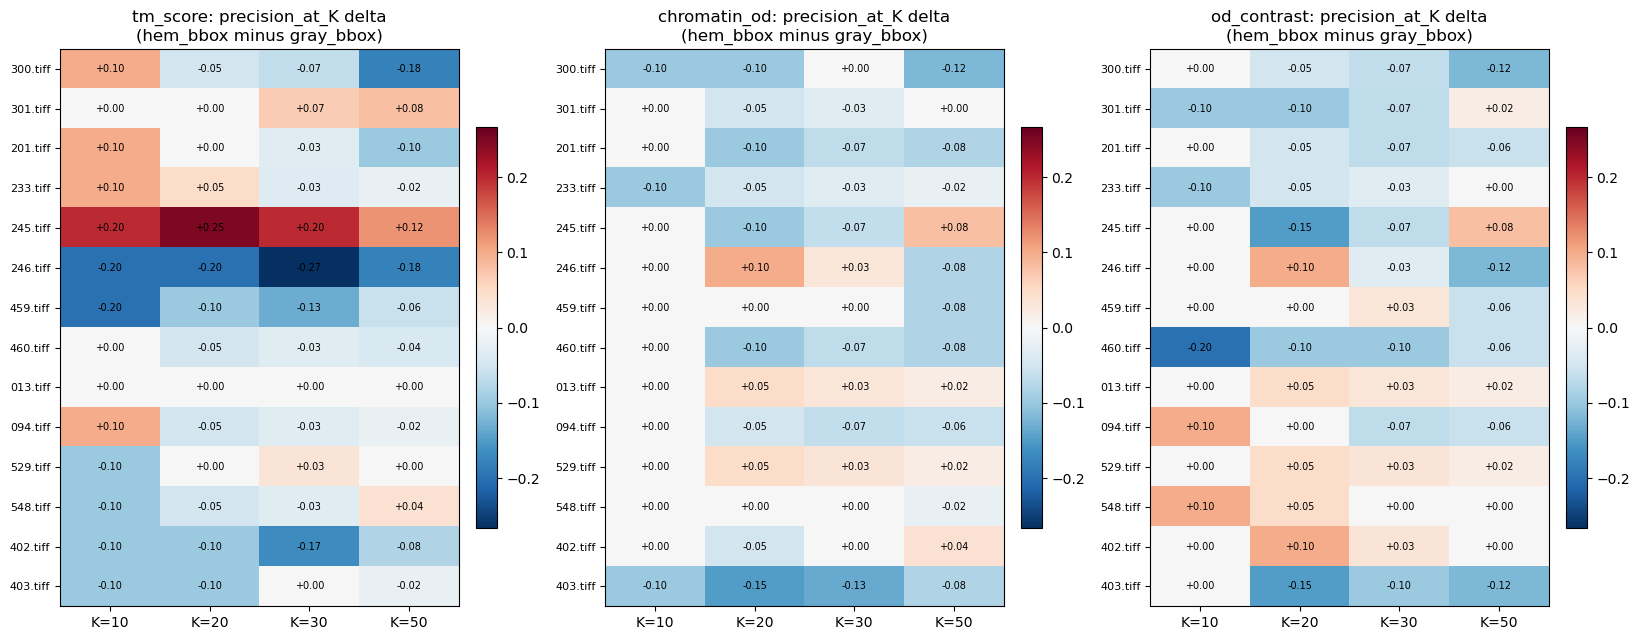

In [15]:
import matplotlib.pyplot as plt

order_files = ROI_CLICK.reset_index().sort_values(['tumor_type', 'file_name'])['file_name'].tolist()

delta_cols = [f'delta_precision_at_{k}' for k in BUDGETS]
lim = max(float(np.abs(DELTA_A[delta_cols].to_numpy()).max()), 1e-6)

fig, axes = plt.subplots(1, len(AXES), figsize=(5.5 * len(AXES), 6.5), squeeze=False)
for ax, arm in zip(axes[0], AXES):
    sub = DELTA_A[DELTA_A['arm'] == arm].set_index('file_name').loc[order_files]
    mat = sub[delta_cols].to_numpy()
    im = ax.imshow(mat, cmap='RdBu_r', vmin=-lim, vmax=lim, aspect='auto')
    ax.set_xticks(range(len(BUDGETS)))
    ax.set_xticklabels([f'K={k}' for k in BUDGETS])
    ax.set_yticks(range(len(order_files)))
    ax.set_yticklabels(order_files, fontsize=8)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f'{mat[i, j]:+.2f}', ha='center', va='center', fontsize=7)
    ax.set_title(f'{arm}: precision_at_K delta\n(hem_bbox minus gray_bbox)')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig('hembbox_roi_delta_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

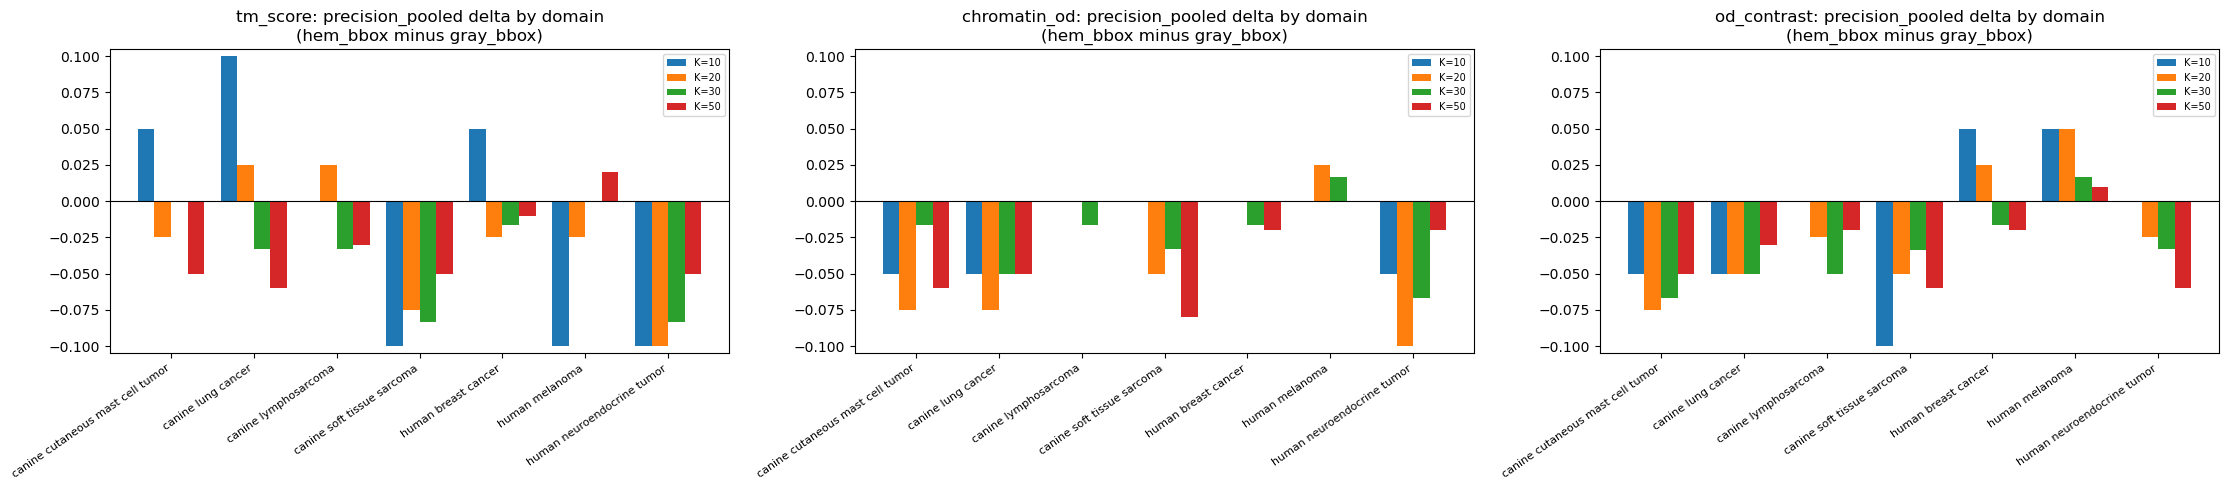

In [16]:
delta_lim = max(float(DELTA_B['delta_precision_pooled'].abs().max()), 1e-6)

fig, axes = plt.subplots(1, len(AXES), figsize=(7.5 * len(AXES), 5), squeeze=False)
for ax, arm in zip(axes[0], AXES):
    sub = DELTA_B[DELTA_B['arm'] == arm]
    domains = sorted(sub['domain'].unique())
    width = 0.8 / len(BUDGETS)
    x = np.arange(len(domains))
    for i, k in enumerate(BUDGETS):
        vals = [sub[(sub['domain'] == d) & (sub['K'] == k)]['delta_precision_pooled'].iloc[0] for d in domains]
        ax.bar(x + i * width, vals, width, label=f'K={k}')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylim(-1.05 * delta_lim, 1.05 * delta_lim)  # 1.05x margin so a bar at exactly delta_lim isn't flush with the frame (audit Finding F9)
    ax.set_xticks(x + width * (len(BUDGETS) - 1) / 2)
    ax.set_xticklabels(domains, rotation=35, ha='right', fontsize=8)
    ax.set_title(f'{arm}: precision_pooled delta by domain\n(hem_bbox minus gray_bbox)')
    ax.legend(fontsize=7)
fig.tight_layout()
fig.savefig('hembbox_domain_delta_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

win/loss/tie counts, all 14 ROIs:
         arm  K  n_roi  wins  losses  ties
    tm_score 10     14     5       6     3
    tm_score 20     14     2       8     4
    tm_score 30     14     3       9     2
    tm_score 50     14     3       9     2
chromatin_od 10     14     0       3    11
chromatin_od 20     14     3       9     2
chromatin_od 30     14     3       7     4
chromatin_od 50     14     4       9     1
 od_contrast 10     14     2       3     9
 od_contrast 20     14     5       7     2
 od_contrast 30     14     4       9     1
 od_contrast 50     14     4       7     3


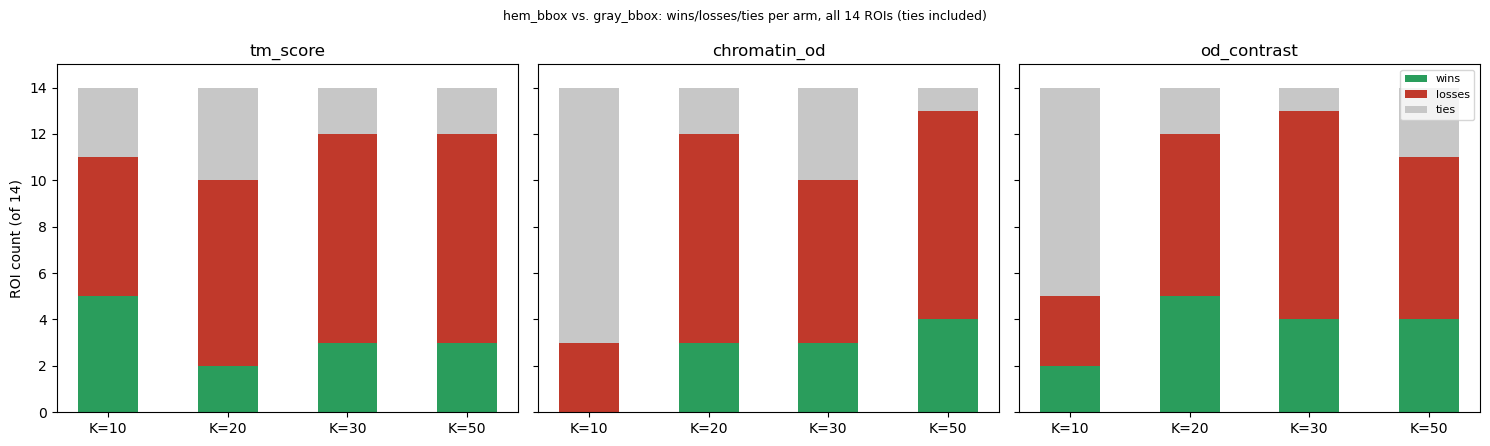

In [17]:
rows_wlt = []
for arm in AXES:
    sub = DELTA_A[DELTA_A['arm'] == arm]
    for k in BUDGETS:
        d = sub[f'delta_exact_at_{k}']
        rows_wlt.append(dict(arm=arm, K=k, n_roi=len(d), wins=int((d > 0).sum()), losses=int((d < 0).sum()), ties=int((d == 0).sum())))
WIN_COUNTS = pd.DataFrame(rows_wlt)
print('win/loss/tie counts, all 14 ROIs:')
print(WIN_COUNTS.to_string(index=False))

fig, axes = plt.subplots(1, len(AXES), figsize=(5 * len(AXES), 4.5), sharey=True)
x = np.arange(len(BUDGETS))
width = 0.5
colors = dict(wins='#2a9d5c', losses='#c0392b', ties='#c7c7c7')
for ax, arm in zip(axes, AXES):
    sub = WIN_COUNTS[WIN_COUNTS['arm'] == arm].set_index('K').loc[list(BUDGETS)]
    bottom = np.zeros(len(BUDGETS))
    for part in ('wins', 'losses', 'ties'):
        ax.bar(x, sub[part], width, bottom=bottom, label=part, color=colors[part])
        bottom = bottom + sub[part].to_numpy()
    ax.set_xticks(x)
    ax.set_xticklabels([f'K={k}' for k in BUDGETS])
    ax.set_title(arm)
    ax.set_ylim(0, 15)
axes[0].set_ylabel('ROI count (of 14)')
axes[-1].legend(fontsize=8, loc='upper right')
fig.suptitle('hem_bbox vs. gray_bbox: wins/losses/ties per arm, all 14 ROIs (ties included)', fontsize=9)
fig.tight_layout()
fig.savefig('hembbox_win_counts.png', dpi=150, bbox_inches='tight')
plt.show()

## Mechanism checks, added after an independent audit

Two more claims in an earlier version of this notebook's closing summary didn't hold up at the
level they were stated
(`Research Logs/2026-09-16-hembbox-precision-at-k-audit-round3.md`, Findings F1 and F3): that the
K=10 tie-heaviness under `chromatin_od`/`od_contrast` was "not evidence the two conditions rank
alike," and that `gray_inverted`'s gate "never refuses a candidate `hematoxylin_od` accepts." Both
were true, narrowly, of what the notebook actually computed at that point (respectively: nothing
about *why* the ties happen; the 18 candidates the one-click-per-ROI RNG walk visited) but read as
broader claims than that supports. The two cells below compute the broader claims directly, rather
than either asserting them or retreating from them.

In [18]:
gate_rows = []
for fn in ROI_CLICK.index:
    rgb = ds.load_roi(f'{IMAGES_DIR}/{fn}')
    roi_shape = rgb.shape
    hem_g = ch.to_channel(rgb, CONDITIONS['hem_bbox'])
    gray_g = ch.to_channel(rgb, CONDITIONS['gray_bbox'])
    gt = ds.image_annotations(annotations, fn)
    pool = ss.border_filter(ss.agreement_pool(gt[gt['category_id'] == ds.MITOTIC])[0], BORDER, roi_shape)
    for _, r in pool.iterrows():
        rcx, rcy = float(r['cx']), float(r['cy'])
        r_hem = ss.tightened_template_box(hem_g, rcx, rcy, otsu_window=OTSU_WINDOW)
        r_gray = ss.tightened_template_box(gray_g, rcx, rcy, otsu_window=OTSU_WINDOW)
        hem_ok = r_hem is not None and tm.read_padded_patch(hem_g, r_hem[1], r_hem[2], CFG.patch_size) is not None
        gray_ok = r_gray is not None and tm.read_padded_patch(hem_g, r_gray[1], r_gray[2], CFG.patch_size) is not None
        gate_rows.append(dict(file_name=fn, ann_id=int(r['ann_id']), hem_accept=hem_ok, gray_accept=gray_ok))
    del hem_g, gray_g
    gc.collect()

GATE_MATRIX = pd.DataFrame(gate_rows)
n_pool = len(GATE_MATRIX)
n_hem = int(GATE_MATRIX['hem_accept'].sum())
n_gray = int(GATE_MATRIX['gray_accept'].sum())
n_hem_only = int((GATE_MATRIX['hem_accept'] & ~GATE_MATRIX['gray_accept']).sum())
n_gray_only = int((~GATE_MATRIX['hem_accept'] & GATE_MATRIX['gray_accept']).sum())
n_joint = int((GATE_MATRIX['hem_accept'] & GATE_MATRIX['gray_accept']).sum())
print(f"pool-wide gate matrix, all 14 ROIs' border-filtered agreement pools, {n_pool} candidates total:")
print(f'  hem_accept: {n_hem}/{n_pool} ({n_hem/n_pool:.1%})   gray_accept: {n_gray}/{n_pool} ({n_gray/n_pool:.1%})')
print(f'  disagreements: {n_hem_only} hem-accepts-gray-refuses, {n_gray_only} gray-accepts-hem-refuses '
     f'({n_hem_only + n_gray_only} total)')
print(f"  joint-accept (both, what this notebook's click is drawn from): {n_joint}/{n_pool} -- "
     f"{n_joint/n_hem:.1%} of hem's own accepted population, {n_joint/n_gray:.1%} of gray's own accepted population")

pool-wide gate matrix, all 14 ROIs' border-filtered agreement pools, 993 candidates total:
  hem_accept: 815/993 (82.1%)   gray_accept: 896/993 (90.2%)
  disagreements: 4 hem-accepts-gray-refuses, 85 gray-accepts-hem-refuses (89 total)
  joint-accept (both, what this notebook's click is drawn from): 811/993 -- 99.5% of hem's own accepted population, 90.5% of gray's own accepted population


In [19]:
def condition_pool(hem, base_size, tpl_xy, mpp):
    '''Rebuilds one condition's post-NMS, chromatin-scored pool -- same recipe as run_condition,
    without the arm-ranking/evaluate_arms machinery, for the top-K object-overlap check below.

    hem (np.ndarray): the search channel.
    base_size (int): this condition's tightened template size.
    tpl_xy (tuple[float, float]): this condition's template centre.
    mpp (float): this ROI's microns-per-pixel.

    Returns pd.DataFrame: the post-NMS pool with score/od51/od_contrast columns.
    '''
    H, W = hem.shape[:2]
    nms_radius = ev.radius_px(mpp, NMS_RADIUS_UM)
    patch = tm.read_padded_patch(hem, *tpl_xy, CFG.patch_size)
    templates, _ = tm.build_augmentations(patch, base_size, CFG.scales, CFG.n_angles, CFG.flips)
    PAD = max((t.shape[0] - 1) // 2 for t in templates)
    hem_p = cv2.copyMakeBorder(hem, PAD, PAD, PAD, PAD, borderType=cv2.BORDER_REPLICATE)
    fused_p, _, valid_p = tm.fused_response(hem_p, templates, CFG.scale_normalize, method=METHOD)
    fused = fused_p[PAD:PAD + H, PAD:PAD + W]
    valid = valid_p[PAD:PAD + H, PAD:PAD + W]
    med, mad = tm.robust_stats(fused, valid)
    cut = med + DEEP_FLOOR_Z * mad
    centers, scores = tm.extract_peaks(fused, valid, PEAK_MIN_DISTANCE, cut, MAX_PEAKS)
    keep = nms_by_distance(centers, scores, nms_radius)
    c, s = centers[keep], scores[keep]
    ok = np.hypot(c[:, 0] - tpl_xy[0], c[:, 1] - tpl_xy[1]) > SELF_HIT_RADIUS
    c, s = c[ok], s[ok]
    pool = pd.DataFrame({'cx': c[:, 0], 'cy': c[:, 1], 'score': s})
    pad = cv2.copyMakeBorder(hem, OD_PAD, OD_PAD, OD_PAD, OD_PAD, cv2.BORDER_REPLICATE)
    px, py = pool['cx'].to_numpy() + OD_PAD, pool['cy'].to_numpy() + OD_PAD
    pool['od51'] = [cm.chromatin_density(pad, x, y, window=OD_WINDOW) for x, y in zip(px, py)]
    pool['od_ctx'] = [cm.chromatin_density(pad, x, y, window=OD_CTX_WINDOW, frac=OD_CTX_FRAC) for x, y in zip(px, py)]
    pool['od_contrast'] = pool['od51'] - pool['od_ctx']
    return pool


overlap_rows = []
for fn in ROI_CLICK.index:
    rgb = ds.load_roi(f'{IMAGES_DIR}/{fn}')
    mpp = ds.roi_mpp(f'{IMAGES_DIR}/{fn}')
    hem_o = ch.to_channel(rgb, SEARCH_CHANNEL)
    gt = ds.image_annotations(annotations, fn)
    seed_ann_id = int(ROI_CLICK.loc[fn, 'seed_ann_id'])
    gt_eval = gt[gt['ann_id'] != seed_ann_id].reset_index(drop=True)
    match_radius = ev.radius_px(mpp, MATCH_RADIUS_UM)

    hits = {}
    for condition in CONDITIONS:
        base_size = int(ROI.loc[(fn, condition), 'base_size'])
        tpl_xy = (float(ROI.loc[(fn, condition), 'tpl_cx']), float(ROI.loc[(fn, condition), 'tpl_cy']))
        pool = condition_pool(hem_o, base_size, tpl_xy, mpp)
        for arm, key in AXES.items():
            top10 = pool.sort_values(key, ascending=False, kind='mergesort').reset_index(drop=True).iloc[:10]
            det_out, _ = ev.bucket_detections(top10, gt_eval, match_radius)
            hits[(condition, arm)] = set(int(a) for a, cat in zip(det_out['matched_ann_id'], det_out['matched_category'])
                                   if a >= 0 and cat == ds.MITOTIC)  # exclude lookalike matches -- "mitoses recovered", not any match
    del hem_o
    gc.collect()

    for arm in AXES:
        h, g = hits[('hem_bbox', arm)], hits[('gray_bbox', arm)]
        overlap_rows.append(dict(file_name=fn, arm=arm, n_hem=len(h), n_gray=len(g),
                                 n_shared=len(h & g), tp_tied=len(h) == len(g)))

OBJECT_OVERLAP = pd.DataFrame(overlap_rows)
OBJECT_OVERLAP.to_csv('../results/precision_at_k_14roi_prodseed_chromatin_hembbox_object_overlap.csv', index=False)
summary = OBJECT_OVERLAP.groupby('arm').agg(mean_hem=('n_hem', 'mean'), mean_gray=('n_gray', 'mean'),
                                            mean_shared=('n_shared', 'mean'), n_tp_tied=('tp_tied', 'sum'),
                                            n=('tp_tied', 'count')).round(3)
print('top-10 object overlap (mitoses recovered), hem_bbox vs gray_bbox, per arm:')
summary

top-10 object overlap (mitoses recovered), hem_bbox vs gray_bbox, per arm:


,mean_hem,mean_gray,mean_shared,n_tp_tied,n
arm,,,,,
chromatin_od,6.357,6.571,5.214,11,14
od_contrast,6.286,6.429,5.286,9,14
tm_score,5.214,5.357,3.714,3,14


## Closing summary

**Rebuilt to the round-2 audit's own specification** (`Research Logs/2026-09-16-hembbox-precision-at-k-audit.md`
and its round-2 follow-up), applying all four required changes together in one rerun: a
joint-validity click gate, `MAX_PEAKS = 100` (D9) with its dependent checks fixed rather than
merely relaxed, `od_contrast` added as a third arm, and no more reliance on an externally-committed,
no-longer-comparable baseline.

**Corrected a second time, after a round-3 audit**
(`Research Logs/2026-09-16-hembbox-precision-at-k-audit-round3.md`), which independently
re-derived essentially every number in this notebook from the raw CSVs and, separately, from
pixels (0 divergences on ~5,800 values across all 28 (ROI, condition) pipeline runs) and found the
arithmetic sound throughout -- but three prose claims below wrong or overstated, all three now
rewritten in place and backed by cells added above rather than asserted: the K=10 tie mechanism
(previously attributed to the peak cap; actually the chromatin axes ranking the same *objects*
regardless of template), the 403.tiff rank number (inherited from an earlier notebook, never
correct for this one's own config, now computed above rather than carried forward), and the
"`gray_inverted` never refuses" claim (true of the 18 candidates this run's own click draws
visited, not of the full candidate pool, now measured over all 993). Every table, every delta,
every p-value and every plotted point the audit checked reproduced exactly.

**The plain answer.** At the production configuration -- one shared click per ROI, `MAX_PEAKS =
100` -- switching the bbox-tightening gate from `gray_inverted` to `hematoxylin_od` makes pooled
precision@K *worse*, in direction, on **all three arms at all four budgets, with no exceptions**:
`tm_score` -1.4 to -3.6pp, `chromatin_od` -2.1 to -3.9pp, `od_contrast` -1.4 to -3.3pp (pooled
across all 14 ROIs; see the delta tables above). But the exact ROI-level sign-flip test (the right
test -- ROI is the paired, exchangeable unit, D5) clears p < 0.05 on exactly **1 of the 12 (arm,
budget) cells** -- `od_contrast` at K=30 (p = 0.047) -- and every other cell, including every
`tm_score` cell, does not (p ranges 0.07-0.83). Those 12 cells are not 12 independent chances at
significance -- the three arms re-rank the same pool and the four budgets are nested prefixes of
one ranked list -- so "1 of 12" already overstates the effective number of tests; correcting for
that would make "not resolvable" an even safer read, not a shakier one. **The honest answer is
still "not resolvable at this design" -- but now in one consistent direction, rather than a
direction that flips depending on which subset of ROIs is read.**

**At K=10, `chromatin_od`/`od_contrast` are tie-heavy because the two conditions recover the same
mitotic objects, not because the production cap leaves no room to differ.** `chromatin_od` ties on
`tp_at_10` on 11/14 ROIs, `od_contrast` on 9/14 -- against `tm_score`'s 3/14. Measured directly
above: the two conditions' post-NMS pools share almost no candidate *points* (only 66 of 1,364
coincide to the pixel across the 14 ROIs, mean Jaccard 0.030) -- the templates really do produce
different candidates, exactly as the "not template-matched" caveat already says. But
`chromatin_od`'s top-10 lists under `hem_bbox` and `gray_bbox` recover, on average, 6.36 and 6.57
of the ROI's mitoses respectively, with **5.21 recovered by both** -- against `tm_score`'s 5.21 and
5.36, with only **3.71** recovered by both (`od_contrast`: 6.29 / 6.43 / **5.29**, ties on 9/14).
`od51`/`od_ctx` are functions of the hematoxylin image *at a location*, with no dependence on which
template produced the candidate sitting there; `tm_score` is the template's own correlation, and
does depend on it. So a changed template moves the candidate *pixels* substantially, but the
chromatin axes still converge on the same real *objects* far more often than the template-dependent
ranker does -- a genuine finding about which axis is more robust to the tightening-channel choice,
not a peak-cap artifact. (Whether this pattern would be *less* pronounced at the old, uncapped pool
size is a different question this run cannot answer -- that comparison would require rebuilding the
retired, non-comparable baseline, which this notebook does not do.)

**The click is identical between conditions on every ROI, verified in Gate 1 above.** Within the 14
candidates the RNG walk actually drew, `hematoxylin_od`'s gate was the one that bound: the joint
click matches a single-channel `hematoxylin_od`-only draw on **14/14** ROIs, but a single-channel
`gray_inverted`-only draw on only **11/14**. Measured over the full 993-candidate pool this drew
from (above), the pattern holds in aggregate but is not absolute: `hematoxylin_od` accepts 815/993
(82.1%), `gray_inverted` accepts 896/993 (90.2%), and of the 89 candidates the two gates disagree
on, 85 are `hematoxylin_od` refusing and only 4 are `gray_inverted` refusing -- so
`hematoxylin_od`'s gate is the more restrictive of the two, clearly, but not one that *never*
refuses something the other accepts. One consequence worth stating plainly: the joint gate this
notebook draws its click from is 811 of those 993 candidates -- 99.5% of `hematoxylin_od`'s own
accepted population but only 90.5% of `gray_inverted`'s. So `gray_bbox` here is `gray_inverted`
tightening evaluated on the clicks `hematoxylin_od` would also have allowed, not on
`gray_inverted`'s full production population. This does not favour either direction in the headline
result -- if anything, restricting `gray_inverted` to hem's easier sub-population can only help
`gray_bbox` look better, not worse -- but it is a scope fact about which population is actually
being compared.

**`base_size` still shrinks on switching to hematoxylin-based tightening -- 13 of 14 ROIs, 1
unchanged, 0 grow now** (median 40px -> 28px, -13.3%), consistent in direction and magnitude with
every earlier version of this notebook, now measured on a run where the click cannot be part of the
explanation. **The "smaller template -> less distinctive -> worse `tm_score`" causal story still
has no support for the arm it was proposed for**: Spearman correlation between `delta_base_size`
and the exact per-arm precision delta is small and non-significant for `tm_score` at every budget
(|rho| <= 0.30, p >= 0.30). Two of the other eight cells (`chromatin_od` at K=20, `od_contrast` at
K=30) are nominally significant (rho = 0.62 and 0.61, p = 0.02-0.03) -- notably in the direction
consistent with the story (more shrinkage, worse precision) rather than against it -- but two of
twelve uncorrected tests is still within chance, and neither axis has `tm_score`'s mechanical link
to template distinctiveness. Not a resolved mechanism either way.

**The `403.tiff` `seed_annulus_empty` exception this notebook family previously found does not
recur here, re-derived above rather than carried forward.** At the old, effectively-uncapped
`MAX_PEAKS`, a deep-rank survivor leaked past NMS by a 0.046px margin traced to the D8 anchor's
half-pixel geometry. At `MAX_PEAKS = 100`, an uncapped re-extraction on `403.tiff` alone (above)
finds that same survivor at rank 4,445 of 53,746 pre-NMS candidates on `hem_bbox` -- nowhere near
the top 100 -- while the self-correlation peak itself still clears where the cap would fall, so
self-hit removal has something to act on; `gray_bbox` has no annulus survivor at all. The D8
half-pixel anchor geometry that produced the old violation is unaffected: still true on 8/14 ROIs
under `hem_bbox`, 9/14 under `gray_bbox` (12/14 under at least one condition) -- it simply has
nothing to act on once the pre-NMS cap removes the candidate that could have leaked through it.

**On the "free simplification" framing this notebook family set out to test:** still holds. Moving
the Otsu bbox-tightening gate onto `hematoxylin_od` is a real code simplification (one channel
conversion instead of two), but it is not behaviourally free -- `base_size` changes on most ROIs and
pooled precision moves in the same (negative) direction on every arm and budget measured here, even
though only one of twelve cells clears significance.

**The pooled mean is not the only view a production decision should see.** Comparing each
condition's own worst ROI (not a paired statistic -- the two conditions' worst ROIs can differ, and
did) tells a different story for `tm_score` than the pooled mean does: `hem_bbox`'s worst ROI
outperforms `gray_bbox`'s worst ROI by **+10.0 / +10.0 / +6.7 / 0.0 pp** at K = 10/20/30/50 --
driven almost entirely by `245.tiff`, the single biggest template shrink in the run (51px -> 23px,
-54.9%), where `hem_bbox` scores 0.30/0.35/0.30/0.24 against `gray_bbox`'s 0.10/0.10/0.10/0.12 at
the same four budgets. `chromatin_od` and `od_contrast` show the opposite pattern at K=20/30 (worst
ROI *worse* under `hem_bbox` by 6.7-15pp) and roughly flat at K=10/50. None of this is a paired
test -- it is one ROI's outcome per condition per cell, with no significance attached -- but reading
burden and worst-case behaviour, not the mean, are this project's own stated product metrics, and a
single-seed design cannot measure the worst-*seed* version of this at all, only this weaker
worst-*ROI* proxy.

**Caveats, stated plainly:**
- *Single-seed.* One click per ROI (`seed_index=0`), not the 5-seed sweep with a paired delta
  clustered at the ROI that this family's own D5 decision sets as the bar for changing the
  production ranker.
- *Not template-matched.* `base_size` differs between conditions on most ROIs -- fixing the click
  (this run's whole point) removes the click/ground-truth confound, it does not make this an
  all-else-equal ranking comparison with the template held fixed.
- *Small G, and tie-heavy at this cap -- for reasons now measured, not assumed (above).* 14 ROIs is
  a low-powered design for an exact sign-flip test; several (arm, K) cells above are dominated by
  ties, which pushes the attainable p-floor up further -- `chromatin_od` at K=10 has only 3 nonzero
  deltas among 14 ROIs, so its p-floor (0.25) makes it unresolvable at *any* effect size, not just
  the one measured. A non-significant result here is "not resolved," not "no effect."
- *K = 50 sits outside D9's own tested range* ("not tested past K=30") -- delivery is fine and
  checked (`budget_delivered == budget` on 336/336), but this is still new ground for the cap, not
  a re-confirmation of it. At this cap the reading-depth family (`read_50`...`read_100`) is almost
  entirely undefined -- `read_50` is finite on 2/14 ROIs, everything deeper on 0/14 -- so nothing
  should be read from those columns at this configuration, regardless of the "for provenance" label
  in the Raw save section above.
- *This run's `gray_bbox` condition is a fresh internal control*, not the previously-committed
  `half_pix_fix` baseline -- it differs on two axes (joint-gated click, D9 cap) from that committed
  output, so no delta in this notebook is comparable to a previously-reported one.
- *`gray_bbox` here is gray tightening on hem's accepted population (90.5% of gray's own), not
  gray's full production population* -- see the gate-matrix note above.
- *Domain-pooled deltas (`DELTA_B`, Figure 2) mix ROIs of different `base_size` deltas within a
  domain* and are more confounded than the per-ROI numbers above.

In [20]:
print(f'notebook ran in {time.time() - NB_T0:.0f}s')

notebook ran in 507s
